# 0. Project idea: Crossplane‑Driven KServe Model Inferencer GUI

And now we should, as project 35, make a thorough plan of the following gui concept "Crossplane-driven KServe Model Inferencer GUI v1.0", whose implementation should constitute project 36: image that we would have a bash script that, when run in a certain environment (Windows, Linux) completely inspects thsi environment. It generates (and stores) a thorough log-report of the system specs, checks whether all necessary software components are present, if not, it installs and prepares them. This bash script would be triggered via the pySide gui button "Inspect & Prepare System". Then the user would browse to the folder containing the onnx model and select (upload) it and its data sets. After that the user would trigger the gui button generate user crossplane account and enter its specs (username, password, etc). Then the user would select the gui button "KServe model inference", which uses Dockerfiles where necessary and starts training, clensing of data sets, feature engineering, drift detection, scraping via Prometheus and retraining via KServe, and stores all artefacts. Finally, by pressing the button "Show" results, the gui would display to the user a detailed Grafana dashboard of all results, drifts, changes, retrainings, features, technical, system or scientific metrics and scores for different backends that we addressed in ONNX project. I know that this is much to take in, but we need to generate a thorough plan and start brainstorming. This would enable us to combine different concepts into one large project as alogical consequence of the hamiltonian cycle analysis and the ONNX gui project, according to the following introduction recommendations: 

>Here are the best free, official, and practice‑oriented introductions for all four technologies, divided by format and use case.
>
>🐋 Docker (The Foundation)  
>Before we start with Kubernetes, we need to understand containers. [1]
>
>Official guide: The [Docker Getting Started Guide](https://docs.docker.com/get-started/) walks us step by step through creating our first container image.  
>Compact text course: The [Docker Handbook on freeCodeCamp](https://www.freecodecamp.org/news/the-docker-handbook/) offers an extremely clear introduction for absolute beginners.
>
>☸️ Kubernetes (The Orchestration Layer)  
>Interactive browser course: The [Kubernetes Basics Tutorial](https://kubernetes.io/docs/tutorials/kubernetes-basics/) from the official documentation lets us try Kubernetes directly in the browser via an interactive terminal—no local installation required. [2, 3]  
>Comprehensive beginner’s guide: The [Kubernetes Handbook from freeCodeCamp](https://www.freecodecamp.org/news/the-kubernetes-handbook/) explains all core concepts (Pods, Services, Deployments) in a very structured way. [4]  
>Practical video tutorial: The [Kubernetes Crash Course for Beginners (YouTube)](https://www.youtube.com/watch?v=s_o8dwzRlu4) shows clearly how to set up Kubernetes locally with Minikube. [5]
>
>🤖 KServe (AI Inference on Kubernetes)  
>Official entry point: The [KServe Welcome & Intro Docs](https://kserve.github.io/website/docs/intro) explain the architecture (Control Plane / Data Plane) and provide direct quickstarts. [6]  
>Hands‑on tutorials:  
>Use the [KServe Predictive Model Guide](https://kserve.github.io/website/docs/getting-started/quickstart-guide) for classical machine‑learning models (e.g., Scikit‑Learn).  
>Use the KServe LLM Guide when we want to host generative AI or large language models. [6]  
>Local setup: The [KServe Quickstart Guide](https://devopscube.com/deploy-ml-model-kubernetes-kserve/) shows exactly how to install KServe efficiently on a local Minikube or kind cluster. [7, 8]
>
>☁️ Crossplane (Infrastructure as Code)  
>Official documentation: The [Crossplane Get Started Guide](https://docs.crossplane.io/latest/get-started/) walks us through installation and shows how to set up our first cloud‑style infrastructure via Kubernetes control. [9, 10]  
>Perfect beginner tutorial: The article [Crossplane for Beginners](https://tamerlan.dev/crossplane-for-beginners-using-the-kubernetes-provider/) on tamerlan.dev uses the Kubernetes Provider. This is brilliant for getting started, because we can test Crossplane without having to link a real, paid AWS or GCP account. [11]
>
>Conceptual video: The [Crossplane Introduction (YouTube)](https://www.youtube.com/watch?v=FpP4o3t2SYk) explains visually in just a few minutes how the reconciliation loops work in the background. [12]
>
>[1] [https://azure.microsoft.com](https://azure.microsoft.com)  
>[2] [https://kubernetes.io](https://kubernetes.io)  
>[3] [https://kubernetes.io](https://kubernetes.io)  
>[4] [https://www.freecodecamp.org](https://www.freecodecamp.org)  
>[5] [https://www.youtube.com](https://www.youtube.com)  
>[6] [https://kserve.github.io](https://kserve.github.io)  
>[7] [https://kserve.github.io](https://kserve.github.io)  
>[8] [https://kserve.github.io](https://kserve.github.io)  
>[9] [https://docs.crossplane.io](https://docs.crossplane.io)  
>[10] [https://docs.crossplane.io](https://docs.crossplane.io)  
>[11] [https://tamerlan.dev](https://tamerlan.dev)  
>[12] [https://www.youtube.com](https://www.youtube.com)

## 0.1: CONCEPT 1 (enterprise, not recommended)

### 1. High‑level concept

**Goal:**  
A PySide‑based GUI that orchestrates a full ML‑inference lifecycle:

1. **Inspect & Prepare System**  
   - Trigger a cross‑platform “environment inspector” script.  
   - Collect system specs, validate dependencies, install missing components.  
   - Persist a detailed log/report.

2. **Upload ONNX Model & Datasets**  
   - User selects ONNX model and associated datasets.  
   - GUI validates structure, stores metadata, and prepares artifacts.

3. **Generate Crossplane User Account**  
   - GUI collects account specs (username, password, etc.).  
   - Uses Crossplane to provision the necessary infrastructure (storage, namespaces, maybe K8s resources).

4. **KServe Model Inference Pipeline**  
   - Build Docker images where needed.  
   - Deploy KServe InferenceService(s) for the ONNX model.  
   - Run data cleansing, feature engineering, drift detection.  
   - Scrape metrics via Prometheus.  
   - Trigger retraining via KServe when drift or performance thresholds are hit.  
   - Store all artifacts (models, logs, metrics, configs).

5. **Show Results (Grafana Dashboard)**  
   - GUI opens or embeds a Grafana dashboard.  
   - Visualizes metrics, drifts, retrainings, features, backend comparisons (aligned with Project 34 ONNX backends).

---

### 2. Button‑to‑pipeline mapping

#### **Button 1: “Inspect & Prepare System”**

**Pipeline:**

- **Frontend (PySide):**
  - Button click → spawn a subprocess.
  - On Windows: call a PowerShell script; on Linux: call a Bash script.
  - Show progress in a log window (tailing the script output).

- **Backend (Script responsibilities):**
  - **System inspection:**
    - OS type, kernel/version.
    - CPU, RAM, disk, GPU presence.
    - Network connectivity basics.
  - **Dependency checks:**
    - Docker / Podman.
    - Kubernetes tooling (`kubectl`, `kind` or `minikube`).
    - KServe CLI / manifests availability.
    - Crossplane CLI (`kubectl crossplane` or Helm charts).
    - Prometheus & Grafana presence (or Helm charts).
  - **Install / prepare if missing:**
    - For local dev: kind/minikube cluster.
    - Install Docker/Podman if not present (where feasible).
    - Deploy Prometheus + Grafana stack into the cluster.
    - Install Crossplane into the cluster.
    - Install KServe into the cluster (Quickstart mode).
  - **Logging:**
    - Write a structured log file (JSON + human‑readable text).
    - Include timestamps, versions, success/failure flags.

**Design choice:**  
- Keep the script **idempotent**: multiple runs should converge the system into a “ready” state, not break it.

---

#### **Button 2: “Upload ONNX Model & Datasets”**

**Pipeline:**

- **Frontend:**
  - File dialog for:
    - ONNX model file(s).
    - Dataset folder(s) (train/validation/test).
  - Show a summary: model path, dataset counts, sizes.

- **Backend:**
  - Validate ONNX model (using ONNX Runtime).
  - Extract input/output signatures (shapes, dtypes).
  - Store metadata in a local JSON (or small SQLite/DuckDB) registry:
    - Model name, version, path.
    - Backend type (Torch‑exported, Sklearn‑converted, etc. from Project 34).
    - Dataset paths and basic stats (rows, columns, missing values).

- **Integration with Project 34:**
  - Reuse ONNX export/metadata logic.
  - Optionally allow re‑export or conversion if the user brings a non‑ONNX model.

---

#### **Button 3: “Generate Crossplane Account”**

**Pipeline:**

- **Frontend:**
  - Form: username, password (or token), project name, environment (dev/stage).
  - Possibly a “dry‑run” toggle.

- **Backend:**
  - Use Crossplane to:
    - Create a **Kubernetes‑backed “pseudo‑cloud”** (for learning, using the Kubernetes provider).
    - Provision:
      - Namespaces for KServe workloads.
      - PersistentVolumeClaims or storage classes for model artifacts.
      - Optional: S3‑like storage via MinIO (provisioned by Crossplane).
  - Store Crossplane resources as YAML in a `crossplane/` folder for reproducibility.
  - Log all reconciliation events (success/failure) into the same log registry.

**Key idea:**  
- For learning and offline use, rely on **Crossplane + Kubernetes provider** (as in tamerlan.dev) instead of real AWS/GCP.

---

#### **Button 4: “KServe Model Inference”**

This is the heart of the pipeline.

**Pipeline:**

- **Frontend:**
  - User selects:
    - Target ONNX model (from registry).
    - Dataset(s) to use.
    - Inference mode: batch, streaming, test vs production.
  - Optionally: thresholds for drift detection, performance metrics.

- **Backend (steps):**

  1. **Docker image preparation:**
     - Build a Docker image that:
       - Contains ONNX Runtime + necessary Python libs.
       - Wraps the model in a KServe‑compatible server (predictive or generative API).
     - Tag and push to local registry (kind/minikube) or Docker daemon.

  2. **KServe InferenceService deployment:**
     - Generate KServe YAML:
       - `InferenceService` with ONNX runtime.
       - Resource requests/limits.
       - Autoscaling hints (HPA/KEDA optional).
     - Apply via `kubectl`.
     - Wait for ready state (polling).

  3. **Data preparation:**
     - Cleanse datasets:
       - Missing values, outliers, normalization.
     - Feature engineering:
       - Derived features, encoding, scaling.
     - Store transformed datasets as artifacts (e.g., in PVC or MinIO).

  4. **Drift detection:**
     - Compare live inference distributions vs training distributions.
     - Use simple statistical tests (KS test, PSI, etc.).
     - Log drift metrics and flags.

  5. **Prometheus scraping:**
     - Ensure KServe exposes metrics (or sidecar).
     - Configure Prometheus to scrape:
       - Latency, throughput, error rates.
       - Drift metrics (if exported).
     - Store metrics in Prometheus TSDB.

  6. **Retraining via KServe:**
     - When drift or performance thresholds are exceeded:
       - Trigger a retraining job (Kubernetes Job or KServe batch pipeline).
       - Use updated datasets.
       - Export new ONNX model.
       - Roll out new version via KServe (canary or blue/green).
     - Log all retraining events and versions.

  7. **Artifact storage:**
     - Models, datasets, logs, metrics, configs:
       - Stored in PVCs / MinIO / local folders.
       - Indexed in metadata registry.

---

#### **Button 5: “Show Results” (Grafana Dashboard)**

**Pipeline:**

- **Frontend:**
  - Button opens:
    - Either an embedded Grafana view (PySide webview).
    - Or launches Grafana in browser with pre‑configured dashboard URL.

- **Backend:**
  - Pre‑provision Grafana dashboards:
    - Panels for:
      - Latency, throughput, error rates.
      - Drift metrics over time.
      - Retraining events (annotations).
      - Feature importance / distribution changes.
      - System metrics (CPU, RAM, GPU).
      - Backend comparison (Torch vs Sklearn vs Custom ONNX from Project 34).
  - Dashboards are defined as JSON and applied via Grafana API or config files.

---

### 3. Architectural layers

To keep it clean and extensible:

1. **GUI Layer (PySide)**  
   - Buttons, forms, progress logs, file dialogs.  
   - Talks to orchestration layer via Python functions/subprocesses.

2. **Orchestration Layer (Python)**  
   - Wraps:
     - System inspection scripts.
     - Crossplane operations.
     - KServe deployments.
     - Prometheus/Grafana interactions.
   - Provides a clean API: `inspect_system()`, `upload_model()`, `provision_crossplane()`, `run_kserve_pipeline()`, `show_dashboard()`.

3. **Infrastructure Layer (Kubernetes + Crossplane)**  
   - kind/minikube cluster.  
   - Crossplane installed with Kubernetes provider.  
   - KServe installed.  
   - Prometheus + Grafana stack.

4. **Model Lifecycle Layer (ONNX + KServe)**  
   - Reuses Project 34’s ONNX metadata and export logic.  
   - Adds KServe deployment and retraining orchestration.

5. **Governance Layer (Logging + Metadata)**  
   - Structured logs (JSON + text).  
   - Metadata registry for:
     - Models, versions, datasets.
     - Crossplane resources.
     - KServe InferenceServices.
     - Drift and retraining events.

---

### 4. Relation to our existing projects

- **Hamiltonian cycle analysis:**  
  - Conceptually, this project is about **orchestrating complex stateful pipelines**— we can reuse the idea of exploring configuration “cycles” or graph‑like relationships between components (models, datasets, clusters, accounts).

- **Project 34 (ONNX GUI):**  
  - Direct reuse:
    - ONNX model registry.
    - Backend conversion logic.
    - Environment validation patterns.
  - Project 35/36 becomes the **deployment and inference layer** on top of that.

---

### 5. Learning path alignment (Docker, K8s, KServe, Crossplane)

We already have the references; we can align them with implementation phases:

1. **Phase 0: Docker basics**  
   - Use Docker Getting Started + freeCodeCamp Docker handbook.  
   - Outcome: we can build and run the ONNX inference image locally.

2. **Phase 1: Kubernetes basics**  
   - Kubernetes Basics (browser tutorial) + freeCodeCamp handbook + Minikube crash course.  
   - Outcome: we can deploy a simple service and understand Pods/Services/Deployments.

3. **Phase 2: KServe**  
   - KServe Welcome & Intro + Predictive Model Guide.  
   - Outcome: we can deploy an ONNX model via KServe on our local cluster.

4. **Phase 3: Crossplane**  
   - Crossplane Get Started + tamerlan.dev tutorial.  
   - Outcome: we can provision Kubernetes resources via Crossplane, using the Kubernetes provider.

5. **Phase 4: Prometheus & Grafana**  
   - Use existing KServe + Prometheus + Grafana examples (like the LLM serving platform repos).  
   - Outcome: we can see metrics and dashboards for our KServe model.

6. **Phase 5: PySide GUI integration**  
   - Wrap all of the above into the GUI buttons and orchestration layer.

---

### 6. Next concrete step

If we keep this as **Project 35 (plan)** and **Project 36 (implementation)**, I’d suggest:

- For Project 35:
  - Finalize:
    - Button mapping.
    - Layered architecture.
    - Minimal YAML/JSON schemas for:
      - Crossplane resources.
      - KServe InferenceService.
      - Prometheus/Grafana dashboards.
  - Write a short “design notes” document (like CERN ML demo style).

- For Project 36:
  - Start with:
    - `inspect_system` script (PowerShell + Bash).
    - Minimal PySide GUI skeleton with the four buttons wired to stub functions.


## 0.2: CONCEPT 2 (cost-free, recommended)

Now we can **rewrite the entire Project 35 concept** under the strict constraint:

### **Everything must run 100% locally, cost‑free, on a private PC (Windows 11 or Linux).**  
No AWS, no GCP, no Azure, no paid providers, no external cloud accounts.  
Only **local Docker/Podman**, **local Kubernetes (kind/minikube)**, **local Crossplane with the Kubernetes Provider**, **local KServe**, **local Prometheus**, **local Grafana**, **local ONNX models**, **local datasets**, **local PySide GUI**.

This is absolutely feasible — and it becomes a beautiful “self‑contained ML‑inference laboratory”.

Below is the **fully rewritten Project 35 plan**, aligned with our constraints.

---

# **Project 35 — Crossplane‑Driven KServe Model Inferencer GUI v1.0 (Local‑Only Edition)**  
### **Complete Architectural Plan for Project 36 Implementation**

---

## **1. Core Vision**

A **PySide GUI** that orchestrates a **fully local, cost‑free ML inference and retraining pipeline**, powered by:

- Local Docker/Podman  
- Local Kubernetes (kind or minikube)  
- Local Crossplane (with Kubernetes Provider only)  
- Local KServe  
- Local Prometheus  
- Local Grafana  
- Local ONNX models  
- Local datasets  
- Local Python environment  
- Local logs, metadata, artifacts  

Everything runs **offline**, on **Windows 11 or Linux**, without any cloud provider.

This becomes a **self‑contained scientific‑computing platform**.

---

## **2. GUI Workflow (Local‑Only)**

### **Button 1 — “Inspect & Prepare System”**

Triggered by PySide → runs:

- On Windows: PowerShell script  
- On Linux: Bash script  

**Script responsibilities:**

1. **System inspection**
   - OS, kernel, CPU, RAM, disk, GPU
   - Docker/Podman presence
   - Kubernetes presence (`kubectl`, `kind`, `minikube`)
   - Helm presence
   - Crossplane presence
   - KServe presence
   - Prometheus/Grafana presence

2. **Install missing components (local only)**
   - Install Docker Desktop or Podman
   - Install kind or minikube
   - Install kubectl
   - Install Helm
   - Install Crossplane (Helm chart)
   - Install KServe (Quickstart manifests)
   - Install Prometheus + Grafana (Helm charts)

3. **Cluster preparation**
   - Create local cluster (kind/minikube)
   - Install Crossplane into cluster
   - Install KServe into cluster
   - Install Prometheus + Grafana into cluster

4. **Logging**
   - Write full inspection report to:
     - `logs/system_inspection.json`
     - `logs/system_inspection.txt`

Everything is **idempotent** — running it twice keeps the system stable.

---

### **Button 2 — “Upload ONNX Model & Datasets”**

User selects:

- ONNX model file  
- Dataset folder(s)  

GUI stores:

- Model metadata (shape, dtype, opset)
- Dataset metadata (rows, columns, missing values)
- Backend type (Torch, Sklearn, Custom)

All stored locally in:

```
registry/models/
registry/datasets/
registry/metadata.json
```

---

### **Button 3 — “Generate Crossplane Account”**

Since everything is local, “account” means:

- A **local Crossplane user profile**  
- A **local namespace**  
- A **local storage bucket** (MinIO or PVC)  
- A **local resource group** (Kubernetes Provider)

GUI collects:

- username  
- password  
- project name  

Backend provisions:

- Crossplane `CompositeResourceDefinition`  
- Crossplane `Composition`  
- Crossplane `Claim`  
- Kubernetes namespace  
- PVC or MinIO bucket  
- ServiceAccount + RBAC  

All YAML stored locally in:

```
crossplane/resources/
crossplane/accounts/
```

No cloud provider involved.

---

### **Button 4 — “KServe Model Inference”**

This is the main pipeline.

#### **Pipeline Steps (Local‑Only)**

1. **Build Docker image**
   - ONNX Runtime + Python + model server
   - Tag and push to local registry (kind/minikube)

2. **Deploy KServe InferenceService**
   - Generate YAML
   - Apply via `kubectl`
   - Wait for ready state

3. **Data preparation**
   - Cleanse datasets
   - Feature engineering
   - Store transformed datasets locally (PVC or MinIO)

4. **Drift detection**
   - Compare live inference vs training distributions
   - PSI, KS test, etc.
   - Store drift metrics locally

5. **Prometheus scraping**
   - Scrape KServe metrics
   - Store in local Prometheus TSDB

6. **Retraining**
   - Trigger Kubernetes Job
   - Re‑export ONNX model
   - Roll out new version via KServe
   - Store retraining logs and artifacts locally

7. **Artifact storage**
   - Models → `artifacts/models/`
   - Datasets → `artifacts/datasets/`
   - Logs → `artifacts/logs/`
   - Metrics → Prometheus TSDB
   - Dashboards → Grafana JSON

Everything stays on the local machine.

---

### **Button 5 — “Show Results”**

GUI opens Grafana dashboard:

- Embedded PySide WebView  
- Or external browser  

Dashboard shows:

- Latency, throughput, error rates  
- Drift metrics  
- Retraining events  
- Feature distributions  
- System metrics (CPU, RAM, GPU)  
- Backend comparison (Torch vs Sklearn vs Custom ONNX)  

All dashboards are local JSON files applied to local Grafana.

---

## **3. Architecture Layers (Local‑Only)**

### **Layer 1 — GUI (PySide)**  
- Buttons  
- Forms  
- Logs  
- WebView for Grafana  

### **Layer 2 — Orchestration (Python)**  
- Wraps system inspection  
- Wraps Crossplane provisioning  
- Wraps KServe deployment  
- Wraps Prometheus/Grafana interactions  

### **Layer 3 — Infrastructure (Local Kubernetes)**  
- kind/minikube cluster  
- Crossplane installed  
- KServe installed  
- Prometheus + Grafana installed  

### **Layer 4 — Model Lifecycle (Local ONNX)**  
- Reuses ONNX metadata logic from Project 34  
- Adds KServe inference + retraining  

### **Layer 5 — Governance (Local Logs + Metadata)**  
- JSON logs  
- YAML manifests  
- Model registry  
- Drift registry  
- Retraining registry  

---

## **4. Learning Path (Local‑Only)**

### **Phase 0 — Docker**
- Build local images  
- Run ONNX inference locally  

### **Phase 1 — Kubernetes**
- Deploy simple services locally  
- Understand Pods/Services/Deployments  

### **Phase 2 — KServe**
- Deploy ONNX model locally  
- Test inference  

### **Phase 3 — Crossplane**
- Provision local resources via Kubernetes Provider  
- No cloud accounts needed  

### **Phase 4 — Prometheus + Grafana**
- Local metrics  
- Local dashboards  

### **Phase 5 — PySide GUI**
- Integrate everything  

---

## **5. Next Steps**

To continue:

- We can define **Module A–I** for Project 35 (like Project 33/34).  
- Or draft the **exact YAML templates** for Crossplane + KServe.  
- Or design the **system inspection script** in detail.  
- Or sketch the **GUI layout** (buttons, tabs, logs, dashboard view).  


# 0.3 GUI sketch

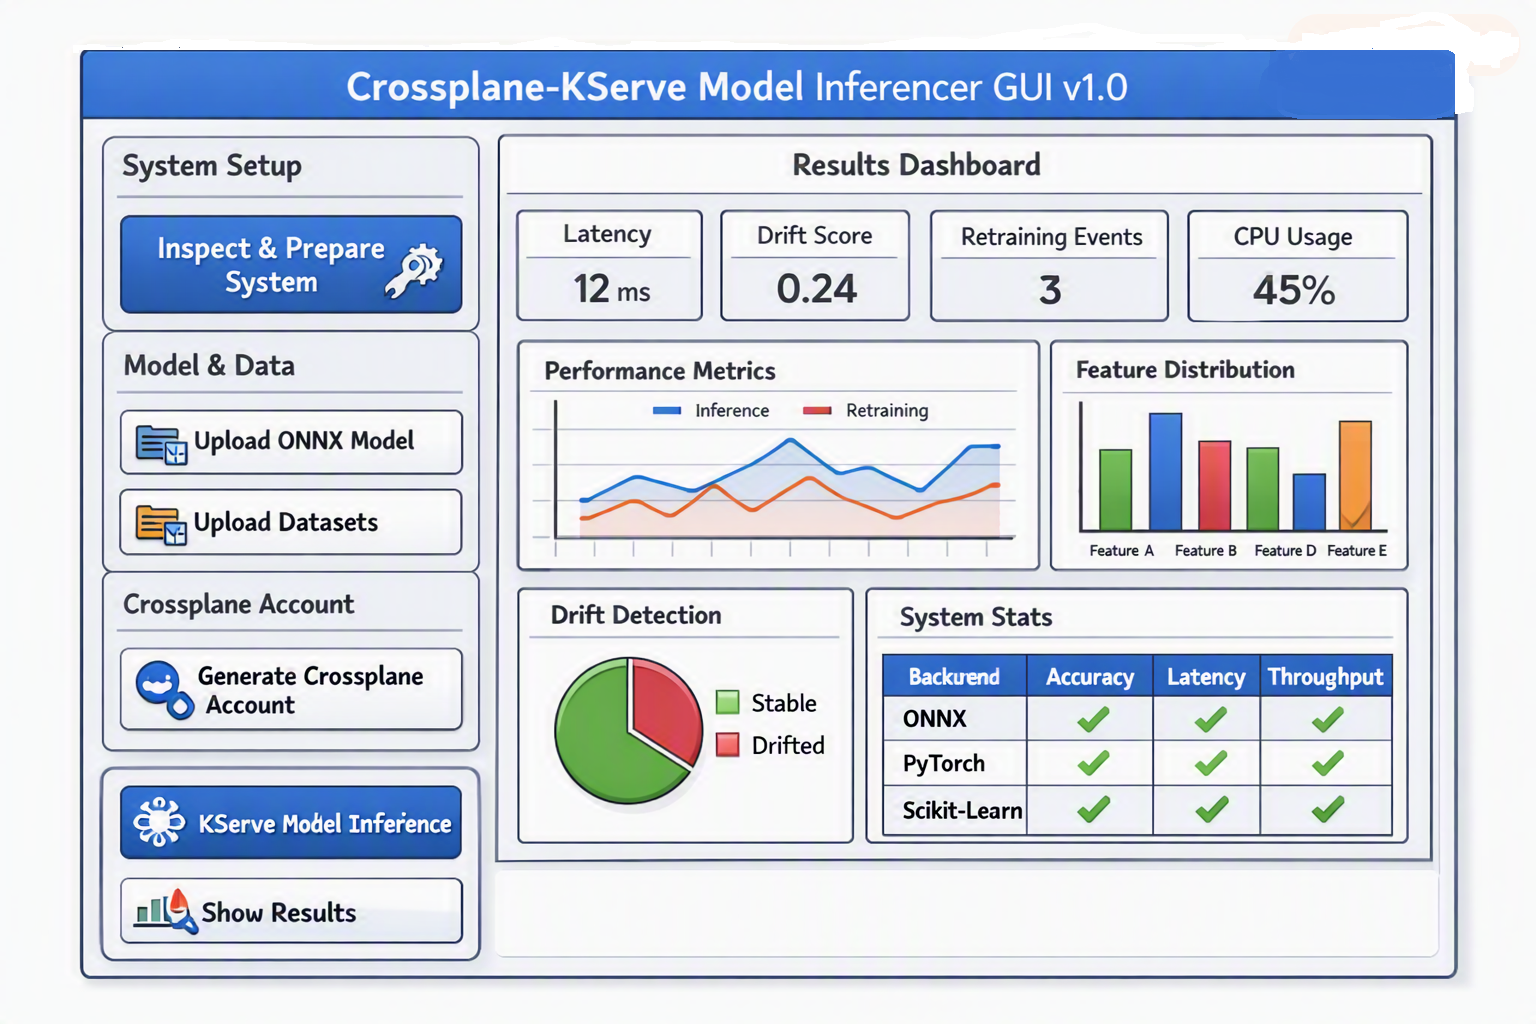

---

### 1. Overall layout

The interface is split into **two main regions**:

- **Left sidebar:** orchestration controls (our five main buttons).
- **Right main panel:** the **Results Dashboard** (Grafana‑style metrics and visualizations).

At the very top, a **blue header bar** shows the title:

> **Crossplane‑Driven KServe Model Inferencer GUI v1.0**

This makes it clear that the app is the central cockpit for our local ML‑inference lab.

---

### 2. Left sidebar — control flow

The left side is a **vertical control panel** that encodes the logical pipeline.

#### **Section A — System Setup**

- **Button:** `Inspect & Prepare System`  
- **Icon:** wrench + gear  

**Functionality:**

- Triggers the **PowerShell/Bash inspection script**.
- Runs environment checks:
  - OS, CPU, RAM, disk, GPU.
  - Docker/Podman, kind/minikube, kubectl, Helm.
  - Crossplane, KServe, Prometheus, Grafana.
- Installs missing components (locally) and prepares the cluster.
- Writes a detailed log to `logs/system_inspection.*`.
- GUI shows a scrolling log window (tail of script output) and a status indicator (Ready / Needs attention).

This is the **entry point**—nothing else should be used before this is green.

---

#### **Section B — Model & Data**

Two buttons:

- **Button 1:** `Upload ONNX Model`  
  - Icon: folder + ONNX logo  
- **Button 2:** `Upload Datasets`  
  - Icon: folder + dataset/grid icon  

**Functionality:**

- `Upload ONNX Model`:
  - Opens a file dialog.
  - Validates the ONNX file (ONNX Runtime).
  - Extracts input/output signatures, opset, shapes.
  - Registers the model in a local registry (Project 34 style).

- `Upload Datasets`:
  - Opens a folder/file dialog.
  - Scans CSV/Parquet/etc.
  - Computes basic stats (rows, columns, missing values).
  - Registers datasets and links them to the selected model.

The GUI can show a small summary below these buttons:

- Selected model name, opset.
- Dataset count, total rows.

---

#### **Section C — Crossplane Account**

- **Button:** `Generate Crossplane Account`  
- **Icon:** key + user  

**Functionality:**

- Opens a dialog:
  - username, password, project name.
- Creates **local Crossplane resources**:
  - Kubernetes namespace.
  - PVC or MinIO bucket.
  - ServiceAccount + RBAC.
  - Crossplane `Composition` + `Claim` using the Kubernetes Provider.
- Stores YAML manifests in `crossplane/resources/`.
- Updates GUI status: “Account ready” with namespace and storage info.

This is our **local infrastructure‑as‑code layer**, but fully offline.

---

#### **Section D — Inference & Training**

- **Button:** `KServe Model Inference`  
- **Icon:** Kubernetes logo + neural network  

**Functionality:**

When clicked, it orchestrates the full pipeline:

1. **Docker image build:**
   - Uses the selected ONNX model.
   - Builds a local image with ONNX Runtime + server code.
   - Pushes to local registry (kind/minikube).

2. **KServe deployment:**
   - Generates `InferenceService` YAML.
   - Applies via `kubectl`.
   - Waits for ready state.

3. **Data preparation:**
   - Cleanses datasets.
   - Performs feature engineering.
   - Stores transformed data as artifacts.

4. **Drift detection:**
   - Compares live inference vs training distributions.
   - Computes drift scores (PSI, KS, etc.).
   - Logs drift metrics.

5. **Prometheus scraping:**
   - Ensures metrics endpoints are scraped.
   - Stores metrics in local Prometheus.

6. **Retraining:**
   - If drift/performance thresholds are exceeded:
     - Triggers retraining job.
     - Exports new ONNX model.
     - Rolls out new KServe version.

The GUI should show a **progress bar** and a **step‑by‑step status list** (e.g., “Building image… Deploying KServe… Running drift detection…”).

---

#### **Section E — Results**

- **Button:** `Show Results`  
- **Icon:** bar chart + magnifying glass  

**Functionality:**

- Opens the **Grafana dashboard**:
  - Either embedded in a PySide WebView.
  - Or in the default browser.
- Uses a pre‑configured dashboard URL (local Grafana).
- Optionally, the GUI can pass parameters (model name, namespace) to filter panels.

This is the **visualization endpoint** of the whole pipeline.

---

### 3. Right side — Results Dashboard

The right panel is a **Grafana‑style dashboard mockup**, but conceptually it’s what you’ll see once Prometheus and Grafana are wired.

#### **Top row — key metrics**

Four metric tiles:

1. **Latency** — e.g., `12 ms`
2. **Drift Score** — e.g., `0.24`
3. **Retraining Events** — e.g., `3`
4. **CPU Usage** — e.g., `45%`

These are **single‑stat panels** that give a quick health snapshot.

---

#### **Middle row — performance & features**

- **Left:** `Performance Metrics` line chart  
  - Two lines:
    - Inference latency over time.
    - Retraining duration or frequency.
  - Time axis (e.g., last 24h).

- **Right:** `Feature Distribution` bar chart  
  - Bars for `Feature A`–`Feature E`.
  - Shows how feature distributions evolve (or current snapshot).

This connects **data behavior** with **system performance**.

---

#### **Lower row — drift & system stats**

- **Left:** `Drift Detection` pie chart  
  - Segments:
    - Stable (green)
    - Drifted (red)
  - Could represent percentage of features or time windows.

- **Right:** `System Stats` box  
  - CPU: `45%`
  - RAM: `8.2 GB`
  - GPU: `Active`

This ties **scientific drift** to **system resource usage**.

---

#### **Bottom — backend comparison**

A table:

- Columns:
  - Backend
  - Accuracy
  - Latency
  - Throughput
- Rows:
  - ONNX
  - PyTorch
  - Scikit‑Learn

This is where **Project 34** plugs in: we can compare different backends for the same task, all locally.

---

### 4. How this GUI reflects our projects

- **Project 34 (ONNX GUI):**  
  - Feeds the “Upload ONNX Model” and backend comparison.
- **Project 35 (this plan):**  
  - Defines the orchestration and visualization.
- **Project 36 (implementation):**  
  - Will turn each button into real code, scripts, YAML, and dashboards.

---


# 1. Functionalities

Now we can start dissecting the GUI **widget by widget**, focusing on what each element measures, stores, and how it interacts with the rest of the system.  
This is the stage where we define the **data flow and metric taxonomy** before we ever write code or the long report.

---

## 🧩 **Widget 1 — System Setup Panel**

### **Purpose**
To give the user a complete overview of the local environment and provide actionable controls to fix or install missing components.

### **Displayed metrics**
- OS type and version  
- CPU model, core count, clock speed  
- RAM total and available  
- Disk space and I/O speed  
- GPU presence and driver version  
- Docker/Podman status  
- Kubernetes cluster status (kind/minikube)  
- Helm, Crossplane, KServe, Prometheus, Grafana installation flags  
- Python environment integrity (version, virtualenv, packages)

### **UX elements**
- Status indicators (green/yellow/red) for each component  
- “Install” buttons next to missing items  
- “Fix Environment” button for full automated repair  
- Expandable log viewer showing inspection output  
- Tooltip help icons linking to official docs

### **Data storage**
- JSON report: `logs/system_inspection.json`  
- Text log: `logs/system_inspection.txt`  
- Optional PDF summary with system specs and reproducibility notes

---

## 📦 **Widget 2 — Model & Data Panel**

### **Purpose**
To manage ONNX models and datasets locally.

### **Displayed metrics**
- Model name, opset, input/output shapes  
- Dataset size, row/column count, missing values  
- Data type distribution  
- Basic statistics (mean, std, min, max per feature)

### **UX elements**
- File dialogs for model and dataset upload  
- Preview table for dataset sample  
- Metadata summary box  
- “Validate Model” and “Analyze Dataset” buttons  
- Status indicator for model readiness

### **Data storage**
- JSON metadata registry: `registry/models.json`, `registry/datasets.json`  
- CSV summaries for dataset stats  
- PDF report (optional) with model schema and dataset overview

---

## 🔐 **Widget 3 — Crossplane Account Panel**

### **Purpose**
To create and manage local Crossplane resources (namespaces, PVCs, MinIO buckets).

### **Displayed metrics**
- Namespace name  
- Storage capacity  
- Resource status (Ready / Pending / Error)  
- YAML manifest preview

### **UX elements**
- Form for username, password, project name  
- “Generate Account” button  
- “View Resources” button (opens YAML viewer)  
- Status indicator for Crossplane reconciliation

### **Data storage**
- YAML manifests: `crossplane/resources/*.yaml`  
- JSON summary: `crossplane/accounts.json`  
- PDF report (optional) describing resource topology and reconciliation logs

---

## ⚙️ **Widget 4 — KServe Model Inference Panel**

### **Purpose**
To orchestrate local inference, training, drift detection, and retraining.

### **Scraped metrics (Prometheus)**

#### **Technical metrics**
- CPU usage (%)
- RAM usage (GB)
- GPU utilization (%)
- Disk I/O
- Network throughput
- Container uptime

#### **Performance metrics**
- Inference latency (ms)
- Throughput (requests/sec)
- Error rate (%)
- Model load time
- Retraining duration

#### **Scientific metrics**
- Accuracy, precision, recall, F1‑score
- Drift score (PSI, KS)
- Feature importance changes
- Retraining frequency
- Dataset freshness (timestamp difference)

#### **Prognostic metrics**
- Trend of drift over time
- Predicted retraining need (simple regression)
- Resource saturation forecast

### **UX elements**
- Progress bar for pipeline stages  
- Real‑time metric charts (Grafana panels embedded)  
- “Start Inference” / “Stop” / “Retrain Now” buttons  
- Dropdown filters for backend (ONNX, Torch, Sklearn)  
- Time‑range selector for metrics (last hour, day, week)

### **Data storage**
- JSON metrics stream (Prometheus export)  
- CSV snapshots for analysis  
- PDF “Explainable AI” report combining:
  - Model performance
  - Drift analysis
  - Retraining decisions
  - Feature importance visualization
  - System resource correlation

---

## 📊 **Widget 5 — Results Dashboard Panel**

### **Purpose**
To visualize all metrics and allow filtering.

### **Dashboard components**
1. **Single‑stat tiles:** latency, drift score, retraining count, CPU usage  
2. **Line chart:** inference latency vs retraining duration  
3. **Bar chart:** feature distributions  
4. **Pie chart:** drift detection (stable vs drifted)  
5. **System stats box:** CPU, RAM, GPU  
6. **Backend comparison table:** accuracy, latency, throughput

### **UX features**
- Filter by model, dataset, backend, time range  
- Hover tooltips with metric explanations  
- Export buttons (JSON, CSV, PDF)  
- “Generate Report” button → creates full XAI PDF  
- “Compare Backends” toggle → overlays multiple models  
- “Drift Timeline” overlay → shows retraining events

### **Data storage**
- JSON dashboard config: `dashboards/config.json`  
- CSV metric exports: `metrics/*.csv`  
- PDF scientific report: `reports/xai_report.pdf`

---

## 🧠 **Widget 6 — Environment Status Footer**

### **Purpose**
To provide a quick health snapshot of the entire system.

### **Displayed metrics**
- Cluster status (Running / Stopped)
- Crossplane reconciliation status
- KServe service health
- Prometheus scrape status
- Grafana dashboard connectivity

### **UX elements**
- Color‑coded indicators  
- “Fix Environment” button (runs full repair script)  
- “Re‑inspect” button (reruns inspection)  
- Tooltip with last inspection timestamp

### **Data storage**
- JSON status file: `status/environment.json`  
- Text log: `status/environment.txt`

---

## 🧩 **Data Storage Summary**

| Data Type | Format | Location | Purpose |
|------------|---------|-----------|----------|
| System inspection | JSON, TXT, PDF | `logs/` | Environment reproducibility |
| Model & dataset metadata | JSON, CSV, PDF | `registry/` | Model lifecycle tracking |
| Crossplane resources | YAML, JSON, PDF | `crossplane/` | Infrastructure reproducibility |
| Metrics & drift | JSON, CSV, PDF | `metrics/`, `reports/` | Performance & scientific analysis |
| Dashboard configs | JSON | `dashboards/` | Visualization reproducibility |
| Environment status | JSON, TXT | `status/` | Health monitoring |

---


Here is a deep dive into the **metric taxonomy** for the Crossplane‑Driven KServe Model Inferencer GUI v1.0.  
This is the foundation for everything else: Grafana dashboards, Prometheus scraping, drift detection, retraining triggers, and XAI reporting.

We will go **very deep** and define:

- **exact Prometheus metric names**  
- **formulas**  
- **categories** (technical, performance, scientific, prognostic)  
- **storage formats**  
- **how the GUI consumes them**  
- **how Grafana filters them**

This is the “metric backbone” of Project 35/36.

---

# **📘 Post 1/3 — Metric Taxonomy (Prometheus + Local KServe + Local Cluster)**

## **1. Why a metric taxonomy matters**

Before building dashboards or retraining logic, we need a **formal metric vocabulary**.  
This ensures:

- reproducibility  
- consistent naming  
- predictable scraping  
- stable Grafana dashboards  
- clean JSON/CSV/PDF exports  
- deterministic retraining triggers  

This taxonomy becomes the **contract** between:

- KServe  
- Prometheus  
- Grafana  
- PySide GUI  
- Drift detection engine  
- Retraining orchestrator  
- XAI report generator  

---

# **2. Metric Categories**

We define **four categories**, each with sub‑metrics.

---

## **A. Technical Metrics (System & Cluster Health)**

These come from:

- Node exporter  
- cAdvisor  
- KServe container metrics  
- Kubernetes API metrics  

### **CPU Metrics**
| Metric Name | Description | Formula |
|-------------|-------------|---------|
| `node_cpu_seconds_total` | Raw CPU time | Provided by node exporter |
| `container_cpu_usage_seconds_total` | CPU usage of KServe container | Provided by cAdvisor |
| `kserve_cpu_usage_percent` | CPU usage % | `(container_cpu_usage_seconds_total / node_cpu_seconds_total) * 100` |

### **Memory Metrics**
| Metric Name | Description |
|-------------|-------------|
| `container_memory_usage_bytes` | Memory used by KServe container |
| `node_memory_MemAvailable_bytes` | Available memory |
| `kserve_memory_usage_percent` | Derived metric |

### **GPU Metrics (if available)**
| Metric Name | Description |
|-------------|-------------|
| `nvidia_gpu_utilization` | GPU usage % |
| `nvidia_gpu_memory_used_bytes` | GPU memory usage |

### **Disk & I/O**
| Metric Name | Description |
|-------------|-------------|
| `node_disk_read_bytes_total` | Disk reads |
| `node_disk_written_bytes_total` | Disk writes |
| `container_fs_usage_bytes` | Container filesystem usage |

### **Network**
| Metric Name | Description |
|-------------|-------------|
| `container_network_receive_bytes_total` | Incoming traffic |
| `container_network_transmit_bytes_total` | Outgoing traffic |

---

## **B. Performance Metrics (Inference Behavior)**

These come from:

- KServe predictor logs  
- KServe metrics endpoint  
- Custom Python instrumentation  

### **Latency**
| Metric Name | Description |
|-------------|-------------|
| `kserve_inference_latency_ms` | Time per inference request |
| `kserve_inference_p95_latency_ms` | 95th percentile latency |
| `kserve_inference_p99_latency_ms` | 99th percentile latency |

### **Throughput**
| Metric Name | Description |
|-------------|-------------|
| `kserve_inference_requests_total` | Total requests |
| `kserve_inference_requests_per_second` | Derived metric |

### **Errors**
| Metric Name | Description |
|-------------|-------------|
| `kserve_inference_errors_total` | Total failed requests |
| `kserve_inference_error_rate_percent` | Derived metric |

### **Model Load Time**
| Metric Name | Description |
|-------------|-------------|
| `kserve_model_load_time_ms` | Time to load ONNX model |

---

## **C. Scientific Metrics (Model Quality & Drift)**

These come from:

- Drift detection engine  
- Feature engineering pipeline  
- Retraining pipeline  

### **Accuracy Metrics**
| Metric Name | Description |
|-------------|-------------|
| `model_accuracy` | Accuracy on validation set |
| `model_precision` | Precision |
| `model_recall` | Recall |
| `model_f1_score` | F1 score |

### **Drift Metrics**
| Metric Name | Description |
|-------------|-------------|
| `drift_psi_score` | Population Stability Index |
| `drift_ks_statistic` | Kolmogorov–Smirnov statistic |
| `drift_feature_change_percent` | % change in feature distribution |
| `drift_detected` | Boolean (0/1) |

### **Feature Importance**
| Metric Name | Description |
|-------------|-------------|
| `feature_importance_weight_{feature}` | Weight per feature |
| `feature_distribution_mean_{feature}` | Mean per feature |
| `feature_distribution_std_{feature}` | Std per feature |

---

## **D. Prognostic Metrics (Predictive Maintenance for ML)**

These are **derived metrics** computed by Python, not Prometheus.

### **Trend Metrics**
| Metric Name | Description |
|-------------|-------------|
| `drift_trend_slope` | Drift increase over time |
| `latency_trend_slope` | Latency trend |
| `accuracy_trend_slope` | Accuracy trend |

### **Forecast Metrics**
| Metric Name | Description |
|-------------|-------------|
| `predicted_retraining_time_hours` | Forecast when retraining will be needed |
| `predicted_drift_score_next_week` | Drift prediction |

### **Resource Forecast**
| Metric Name | Description |
|-------------|-------------|
| `cpu_saturation_forecast_percent` | Predicted CPU saturation |
| `memory_saturation_forecast_percent` | Predicted RAM saturation |

---

# **3. Storage Formats**

### **JSON**
- Raw Prometheus metrics  
- Drift detection results  
- Feature distributions  
- Forecast metrics  
- Used by GUI and Grafana

### **CSV**
- Time‑series exports  
- Dataset summaries  
- Feature distributions  
- Useful for offline analysis

### **PDF (XAI Report)**
Contains:

- Model architecture summary  
- ONNX metadata  
- Dataset overview  
- Drift analysis  
- Feature importance  
- Retraining decisions  
- System resource correlation  
- Backend comparison  

This is the **scientific deliverable**.

---

# **4. How the GUI uses these metrics**

### **System Setup Panel**
- Reads technical metrics  
- Shows environment health indicators  
- Provides “Fix Environment” button

### **Model & Data Panel**
- Shows dataset stats  
- Shows model metadata

### **Inference Panel**
- Shows performance metrics  
- Shows drift metrics  
- Shows retraining triggers

### **Results Dashboard**
- Grafana panels fed by Prometheus  
- Filters:
  - Time range  
  - Backend  
  - Model version  
  - Dataset version  
  - Drift threshold  

### **Report Generation**
- Uses JSON + CSV + Prometheus snapshots  
- Produces PDF with XAI content

Below is a **deep, structured, backend‑aware explanation** of how the GUI will treat metrics from **different model backends**:

- **MLServer**  
- **Scikit‑Learn (sklearn)**  
- **PyTorch**  
- **Triton Inference Server**  
- **Custom Python ONNX Runtime server**

This is crucial because each backend exposes **different metrics**, in **different formats**, through **different endpoints**, and with **different semantics**.

We need a unified strategy so that the GUI and Grafana dashboards can treat them **consistently**, while still preserving backend‑specific richness.

Let’s break it down.

---

# ⭐ **How the GUI Handles Metrics Across Different Backends**

## **1. The Core Principle: Unified Metric Schema**

All backends produce metrics → GUI normalizes them → Grafana visualizes them.

We define a **Unified Metric Schema (UMS)**:

```
ums_<backend>_<metric_name>
```

Examples:

- `ums_torch_latency_ms`
- `ums_sklearn_accuracy`
- `ums_mlserver_requests_total`
- `ums_triton_gpu_utilization`
- `ums_custom_feature_drift_score`

This ensures:

- No naming collisions  
- No ambiguity  
- Easy filtering by backend  
- Easy filtering by metric type  
- Easy filtering by model version  

The GUI uses this schema internally and exposes it to Grafana.

---

# ⭐ **2. Backend‑Specific Metric Capabilities**

Each backend has different strengths.  
We must respect that.

---

## **A. MLServer Metrics**

MLServer exposes metrics via:

- Prometheus endpoint  
- Model‑specific metrics  
- Server‑level metrics  

### **Available metrics**
- `mlserver_inference_requests_total`
- `mlserver_inference_request_duration_seconds`
- `mlserver_inference_errors_total`
- `mlserver_model_load_time_seconds`
- `mlserver_queue_time_seconds`

### **GUI mapping**
- `ums_mlserver_latency_ms`
- `ums_mlserver_throughput_rps`
- `ums_mlserver_error_rate_percent`
- `ums_mlserver_load_time_ms`

### **Special notes**
MLServer is very structured → easiest to integrate.

---

## **B. Scikit‑Learn Metrics**

Sklearn itself does **not** expose runtime metrics.  
We must generate them manually.

### **Available metrics (computed by Python)**
- Accuracy  
- Precision  
- Recall  
- F1 score  
- Drift metrics (PSI, KS)  
- Feature importance (if model supports it)

### **GUI mapping**
- `ums_sklearn_accuracy`
- `ums_sklearn_precision`
- `ums_sklearn_recall`
- `ums_sklearn_f1`
- `ums_sklearn_drift_psi`
- `ums_sklearn_feature_importance_{feature}`

### **Special notes**
Sklearn is **offline**, so metrics are computed during:

- Data preparation  
- Drift detection  
- Retraining  

Not during inference.

---

## **C. PyTorch Metrics**

PyTorch models deployed via ONNX Runtime or TorchServe/KServe expose:

### **Available metrics**
- Latency  
- Throughput  
- GPU utilization  
- Memory usage  
- Model load time  
- Error rate  

### **GUI mapping**
- `ums_torch_latency_ms`
- `ums_torch_throughput_rps`
- `ums_torch_gpu_utilization`
- `ums_torch_memory_usage_bytes`
- `ums_torch_error_rate_percent`

### **Special notes**
PyTorch is the most flexible backend → can expose custom metrics.

---

## **D. Triton Inference Server Metrics**

Triton is extremely rich in metrics.

### **Available metrics**
- `nv_inference_request_duration_us`
- `nv_inference_count`
- `nv_inference_exec_count`
- `nv_inference_queue_duration_us`
- `nv_gpu_utilization`
- `nv_gpu_memory_used_bytes`

### **GUI mapping**
- `ums_triton_latency_ms`
- `ums_triton_throughput_rps`
- `ums_triton_queue_time_ms`
- `ums_triton_gpu_utilization`
- `ums_triton_gpu_memory_bytes`

### **Special notes**
Triton is the **gold standard** for metrics.

---

## **E. Custom Python ONNX Runtime Server**

Custom servers expose metrics via:

- Python instrumentation  
- Prometheus client library  

### **Available metrics**
- Latency  
- Throughput  
- Error rate  
- Drift metrics  
- Feature importance  
- Retraining events  

### **GUI mapping**
- `ums_custom_latency_ms`
- `ums_custom_throughput_rps`
- `ums_custom_error_rate_percent`
- `ums_custom_drift_score`
- `ums_custom_retraining_events_total`

### **Special notes**
Custom backend is the most flexible → can expose anything.

---

# ⭐ **3. How the GUI Normalizes Metrics**

The GUI uses a **backend adapter layer**:

```
BackendMetricAdapter
```

Each backend has its own adapter:

- `MLServerAdapter`
- `SklearnAdapter`
- `TorchAdapter`
- `TritonAdapter`
- `CustomAdapter`

Each adapter:

1. Scrapes raw metrics  
2. Converts them to UMS format  
3. Stores them in JSON/CSV  
4. Pushes them to Prometheus  
5. Updates Grafana dashboards  

This ensures **backend differences disappear** at the GUI level.

---

# ⭐ **4. How Grafana Handles Backend Differences**

Grafana dashboards use:

### **Filters**
- Backend (dropdown)
- Model version
- Dataset version
- Time range
- Drift threshold
- Metric type (technical/performance/scientific)

### **Panels**
Each panel uses queries like:

```
ums_<backend>_<metric_name>
```

Example:

```
ums_torch_latency_ms
ums_mlserver_latency_ms
ums_triton_latency_ms
```

Grafana can overlay multiple backends in one chart.

---

# ⭐ **5. How Metrics Are Stored**

### **JSON**
- Raw metrics  
- Drift results  
- Feature distributions  
- Backend metadata  

### **CSV**
- Time‑series exports  
- Feature distributions  
- Drift snapshots  

### **PDF (XAI Report)**
Includes:

- Backend comparison  
- Model performance  
- Drift analysis  
- Retraining decisions  
- Feature importance  
- System resource correlation  

---

# ⭐ **6. How the GUI Displays Backend Differences**

### **Backend Comparison Table**
Columns:

- Accuracy  
- Latency  
- Throughput  
- Drift score  
- Retraining count  
- GPU utilization  

Rows:

- ONNX  
- PyTorch  
- Sklearn  
- MLServer  
- Triton  
- Custom  

### **Backend‑specific panels**
Each backend gets:

- Latency chart  
- Throughput chart  
- Drift chart  
- Feature distribution chart  
- Resource usage chart  

---

# ⭐ **7. Summary**

The GUI treats backend metrics by:

1. Scraping raw backend metrics  
2. Normalizing them into a unified schema  
3. Storing them in JSON/CSV/PDF  
4. Feeding them into Prometheus  
5. Visualizing them in Grafana  
6. Allowing filtering by backend  
7. Comparing backends in unified dashboards  

This ensures:

- Consistency  
- Reproducibility  
- Scientific rigor  
- Backend‑agnostic UX

---

# **5. Next Step**

Post **2/3** will cover:

### **UX Filtering Logic**  
How users select:

- time ranges  
- backends  
- parameters  
- drift thresholds  
- model versions  
- dataset versions  

And how Grafana + PySide cooperate to provide a seamless UX.


Here is a deep, architectural exploration of the **UX Filtering Logic** for the Crossplane‑Driven KServe Model Inferencer GUI v1.0.

This is the part where we define *how the user interacts with metrics*, *how Grafana dashboards respond*, and *how the GUI orchestrates filtering across backends, models, datasets, time ranges, drift thresholds, and scientific parameters*.

This is the “human‑machine interaction layer” of Project 35/36.

---

# **📘 Post 2/3 — UX Filtering Logic (GUI + Grafana + Prometheus)**

The goal is to design a **clean, intuitive, scientific UX** that allows users to explore:

- technical metrics  
- performance metrics  
- scientific metrics  
- drift metrics  
- retraining events  
- backend comparisons  

…without overwhelming them.

We will define:

1. **Filtering dimensions**  
2. **GUI controls**  
3. **Grafana dashboard integration**  
4. **Backend‑aware filtering**  
5. **Time‑range logic**  
6. **Parameter filtering**  
7. **Advanced UX features**  
8. **Storage and reproducibility**

Let’s go deep.

---

# **1. Filtering Dimensions (The Axes of Exploration)**

The GUI must allow filtering across **seven dimensions**:

### **A. Time Range**
- Last 5 minutes  
- Last 1 hour  
- Last 24 hours  
- Last 7 days  
- Custom range  

### **B. Backend**
- ONNX Runtime  
- PyTorch  
- Scikit‑Learn  
- MLServer  
- Triton  
- Custom Python  

### **C. Model Version**
- v1.0  
- v1.1 (after retraining)  
- v1.2 (after drift correction)  
- etc.

### **D. Dataset Version**
- training_v1  
- validation_v1  
- retraining_v2  
- drift_corrected_v3  

### **E. Drift Threshold**
- PSI threshold  
- KS threshold  
- Feature‑change threshold  

### **F. Metric Type**
- Technical  
- Performance  
- Scientific  
- Drift  
- Prognostic  

### **G. Namespace / Crossplane Account**
- user1  
- user2  
- projectA  
- projectB  

These seven axes define the **complete filtering space**.

---

# **2. GUI Controls (PySide Widgets)**

The GUI will expose filtering controls in a **right‑side panel** or **top toolbar**.

### **A. Time Range Selector**
A dropdown + calendar widget:

```
[ Last 1h ▼ ] [ Custom Range ]
```

### **B. Backend Selector**
A multi‑select dropdown:

```
[ ONNX ] [ PyTorch ] [ Sklearn ] [ MLServer ] [ Triton ] [ Custom ]
```

### **C. Model Version Selector**
A dropdown populated from metadata registry:

```
Model Version: [ v1.2 ▼ ]
```

### **D. Dataset Selector**
A dropdown:

```
Dataset: [ training_v1 ▼ ]
```

### **E. Drift Threshold Slider**
A slider + numeric input:

```
Drift Threshold (PSI): [ 0.20 ----|------ 0.50 ]
```

### **F. Metric Type Tabs**
Tabs across the top:

```
[ Technical ] [ Performance ] [ Scientific ] [ Drift ] [ Prognostic ]
```

### **G. Namespace Selector**
Dropdown:

```
Namespace: [ user1-projectA ▼ ]
```

### **H. “Apply Filters” Button**
Explicit apply button to avoid auto‑refresh overload.

---

# **3. Grafana Dashboard Integration**

Grafana dashboards will be embedded in a PySide WebView.

### **Filtering Mechanism**
Grafana supports:

- **URL parameters**  
- **Variables**  
- **Templating**  
- **Dashboard JSON**  

The GUI will update Grafana variables via:

- URL query strings  
- HTTP API calls  
- Dashboard variable injection  

Example:

```
http://localhost:3000/d/model-dashboard?var-backend=triton&var-time=1h&var-model=v1.2
```

The GUI constructs this URL dynamically.

---

# **4. Backend‑Aware Filtering**

Backend filtering is crucial because:

- Triton exposes GPU metrics  
- MLServer exposes queue metrics  
- Sklearn exposes offline metrics  
- Custom backend exposes drift metrics  
- ONNX Runtime exposes minimal metrics  

### **Logic**
When user selects:

```
Backend = Triton
```

The GUI:

- Enables GPU panels  
- Enables queue‑time panels  
- Disables offline metrics  
- Highlights Triton‑specific charts  

When user selects:

```
Backend = Sklearn
```

The GUI:

- Enables accuracy/precision/recall panels  
- Enables drift panels  
- Disables GPU panels  
- Disables latency panels (unless wrapped in KServe)

This ensures **backend‑specific UX** without confusion.

---

# **5. Time‑Range Logic**

Time range affects:

- Prometheus queries  
- Grafana panels  
- Trend analysis  
- Forecast metrics  

### **Prometheus Query Example**

```
rate(ums_triton_latency_ms[1h])
```

### **GUI Logic**
When user selects:

```
Last 24 hours
```

The GUI:

- Updates Grafana variable `var-time=24h`
- Updates Prometheus query window
- Updates drift trend slope calculation
- Updates retraining timeline

---

# **6. Parameter Filtering**

### **Drift Threshold**
User sets PSI threshold:

```
PSI > 0.25 → drift detected
```

GUI updates:

- Drift pie chart  
- Drift timeline  
- Retraining triggers  
- XAI report sections  

### **Model Version**
Selecting model version updates:

- All metrics to that version  
- All retraining events  
- All drift events  
- All feature distributions  

### **Dataset Version**
Selecting dataset version updates:

- Feature distributions  
- Drift calculations  
- Accuracy metrics  

---

# **7. Advanced UX Features**

### **A. Multi‑backend overlay**
User selects:

```
ONNX + Triton + PyTorch
```

Grafana overlays latency curves:

- Blue → ONNX  
- Red → Triton  
- Green → PyTorch  

### **B. Drift timeline overlay**
Shows:

- Drift spikes  
- Retraining events  
- Model version changes  

### **C. Feature importance comparison**
User selects:

```
Feature A
```

Grafana shows:

- Importance over time  
- Drift over time  
- Backend comparison  

### **D. Scientific correlation view**
User selects:

```
Latency vs Drift
```

Grafana shows:

- Scatter plot  
- Regression line  
- Correlation coefficient  

### **E. “Freeze Dashboard”**
Locks current filters and allows exporting:

- JSON  
- CSV  
- PDF (XAI report)

---

# **8. Storage & Reproducibility**

### **JSON**
Stores:

- Current filter state  
- Dashboard variable state  
- Backend selection  
- Time range  
- Drift threshold  

### **CSV**
Stores:

- Filtered metric snapshots  
- Time‑series exports  

### **PDF**
Stores:

- Filtered XAI report  
- Backend comparison  
- Drift analysis  
- Scientific metrics  

### **Location**
```
dashboards/state.json
dashboards/exports/*.csv
reports/xai/*.pdf
```

---

# **Summary of UX Filtering Logic**

The GUI provides:

- **7 filtering dimensions**  
- **backend‑aware UX**  
- **Grafana variable injection**  
- **Prometheus query adaptation**  
- **scientific filtering**  
- **drift threshold control**  
- **model/dataset version selection**  
- **multi‑backend overlays**  
- **exportable dashboards**  

This creates a **scientific, reproducible, user‑friendly UX** for exploring ML inference behavior.

---


Now we combine the two remaining pillars:

- **Report Generation — XAI PDF Structure**  
- **Environment Repair Logic — “Fix Environment” Button**

This is where the platform becomes not just a monitoring tool, but a **scientific instrument** and a **self‑healing system**.

---

## 📘 Part 1 — Report Generation (XAI PDF Structure)

### 1. Purpose of the XAI Report

The PDF is the **human‑readable, archival artifact** that captures:

- What model ran  
- On which data  
- In which environment  
- With which performance  
- Under which drift conditions  
- With which retraining decisions  
- And how resources behaved  

It’s meant for:

- HPC/ML engineers  
- auditors  
- consultants  
- scientific collaborators  

### 2. High‑level structure

**Section 1 — Cover & Metadata**

- **Title:**  
  “Crossplane‑Driven KServe Model Inferencer — XAI Report”

- **Metadata:**  
  - Model name, backend (ONNX/Triton/Torch/etc.)  
  - Model version  
  - Dataset version(s)  
  - Namespace / Crossplane account  
  - Time range covered  
  - Report generation timestamp  
  - System ID (hash of environment inspection JSON)

---

**Section 2 — Environment & Infrastructure Overview**

- **System specs:**  
  - OS, CPU, RAM, GPU, disk  
  - Docker/Podman version  
  - Kubernetes cluster type (kind/minikube)  
  - Crossplane, KServe, Prometheus, Grafana versions  

- **Cluster topology (high‑level):**  
  - Namespaces  
  - KServe InferenceService(s)  
  - PVCs / MinIO buckets  
  - ServiceAccounts  

- **Reproducibility note:**  
  - Paths to YAML manifests  
  - Paths to inspection logs  

---

**Section 3 — Model & Data Description**

- **Model:**  
  - ONNX metadata (inputs, outputs, opset, shapes)  
  - Backend (Torch, Sklearn, MLServer, Triton, Custom)  
  - Training objective (classification/regression/etc.)

- **Datasets:**  
  - Training/validation/test dataset summaries  
  - Row/column counts  
  - Feature types  
  - Missing value stats  

- **Feature overview:**  
  - List of features  
  - Basic statistics (mean, std, min, max)  

---

**Section 4 — Performance Metrics**

- **Latency:**  
  - Mean, median, p95, p99  
  - Time‑series plots  

- **Throughput:**  
  - Requests/sec over time  

- **Error rates:**  
  - Total errors  
  - Error rate %  

- **Model load time:**  
  - Initial load time  
  - Reload times (if retrained)

Visuals:

- Line charts (latency, throughput)  
- Single‑stat tiles (p95 latency, error rate)

---

**Section 5 — Scientific Metrics & Drift Analysis**

- **Accuracy metrics:**  
  - Accuracy, precision, recall, F1  

- **Drift metrics:**  
  - PSI per feature  
  - KS statistic per feature  
  - Drift score summary  

- **Drift timeline:**  
  - When drift was detected  
  - Severity over time  

Visuals:

- Bar charts (feature drift)  
- Timeline plots (drift score vs time)  
- Tables (features with highest drift)

---

**Section 6 — Retraining & Versioning**

- **Retraining events:**  
  - Timestamps  
  - Trigger reason (drift threshold, performance drop)  
  - Dataset version used  
  - New model version ID  

- **Version comparison:**  
  - v1.0 vs v1.1 vs v1.2  
  - Accuracy/latency changes  
  - Drift reduction  

Visuals:

- Table of versions and metrics  
- Line chart showing performance across versions  

---

**Section 7 — Backend Comparison (If multiple backends used)**

- ONNX vs Triton vs Torch vs Sklearn vs MLServer vs Custom:

  - Accuracy  
  - Latency  
  - Throughput  
  - Drift score  
  - Resource usage (CPU/GPU)

Visuals:

- Comparison table  
- Overlay charts (latency curves, accuracy bars)

---

**Section 8 — Resource & System Behavior**

- CPU, RAM, GPU usage over time  
- Disk and network I/O  
- Correlation between resource usage and performance/drift

Visuals:

- Line charts (CPU/GPU usage)  
- Scatter plots (latency vs CPU, drift vs GPU)

---

**Section 9 — Explainability & Interpretation**

- Narrative explanation of:

  - Why drift occurred  
  - Why retraining was triggered  
  - How feature importance changed  
  - How backend choice affected performance  

- “Key insights” bullet list:

  - e.g., “Feature X is highly unstable and drives drift.”  
  - “Triton backend yields lower latency but similar accuracy.”  
  - “Retraining every 48h stabilizes drift below PSI 0.2.”

---

**Section 10 — Reproducibility & Artifacts**

- Paths to:

  - JSON metrics  
  - CSV exports  
  - YAML manifests  
  - ONNX models  
  - Datasets  

- Hashes for:

  - Model files  
  - Dataset files  
  - Environment inspection report  

This section makes the report **auditable and reproducible**.

---

## 📘 Part 2 — Environment Repair Logic (“Fix Environment” Button)

Now, the **self‑healing** part.

### 1. Purpose

The “Fix Environment” button is the **panic button** and the **maintenance button**:

- When something breaks  
- When dependencies drift  
- When cluster state is inconsistent  
- When user wants a clean, reproducible baseline  

It runs a **controlled, idempotent repair pipeline**.

---

### 2. High‑level behavior

When user clicks **“Fix Environment”**:

1. GUI asks for confirmation (to avoid accidental resets).  
2. GUI triggers a **repair script** (PowerShell on Windows, Bash on Linux).  
3. Script reads the latest `logs/system_inspection.json`.  
4. Script compares desired state vs actual state.  
5. Script performs:

   - dependency repair  
   - cluster repair  
   - service repair  

6. GUI shows a live log of actions.  
7. At the end, GUI re‑runs a **fresh inspection** and updates status.

---

### 3. Desired State Model

We define a **Desired State JSON**:

```json
{
  "docker": "installed",
  "kubernetes_cluster": "running",
  "crossplane": "installed",
  "kserve": "installed",
  "prometheus": "installed",
  "grafana": "installed",
  "python_env": "healthy"
}
```

The repair script aims to **converge** the system to this state.

---

### 4. Repair Steps

#### A. Docker/Podman

- If not installed → prompt user or install (where feasible).  
- If not running → start service.  
- If misconfigured → reset basic config.

#### B. Kubernetes Cluster (kind/minikube)

- If cluster not present → create new cluster.  
- If cluster unhealthy → delete and recreate (with warning).  
- If kubeconfig broken → regenerate.

#### C. Crossplane

- If not installed → install via Helm.  
- If CRDs missing → re‑apply.  
- If reconciliation failing → restart Crossplane pods.

#### D. KServe

- If not installed → apply Quickstart manifests.  
- If InferenceService CRDs missing → re‑apply.  
- If KServe pods failing → restart or redeploy.

#### E. Prometheus & Grafana

- If not installed → install via Helm.  
- If services failing → restart.  
- If dashboards missing → re‑apply JSON configs.

#### F. Python Environment

- Check Python version.  
- Check required packages (onnxruntime, prometheus_client, etc.).  
- If missing → install via pip/conda.  
- If environment corrupted → suggest recreating venv/conda env.

---

### 5. Idempotency & Safety

- Repair script is **idempotent**: multiple runs converge to the same healthy state.  
- Destructive actions (cluster recreation) require explicit user confirmation.  
- Logs are written to:

  - `logs/environment_fix.txt`  
  - `logs/environment_fix.json`

---

### 6. GUI Integration

The GUI:

- Shows a **status panel**:

  - Docker: ✅/⚠️/❌  
  - Cluster: ✅/⚠️/❌  
  - Crossplane: ✅/⚠️/❌  
  - KServe: ✅/⚠️/❌  
  - Prometheus/Grafana: ✅/⚠️/❌  
  - Python env: ✅/⚠️/❌  

- Provides:

  - “Fix Environment” (global repair)  
  - “Fix Component” (per‑service repair, e.g., only KServe)  

- After repair:

  - Automatically re‑runs inspection  
  - Updates environment status  
  - Logs a “repair event” that can be referenced in XAI reports (e.g., “Environment repaired at 2026‑08‑15 18:42”).

---

### 7. Relation to XAI Report

The XAI report can include:

- A section “Environment Events”:

  - Inspection timestamps  
  - Repair timestamps  
  - Changes in versions/configs  

This ties **model behavior** to **environment changes**, which is crucial for serious scientific governance.

---

## 🔚 Summary

With this third post, we now have:

- A **rich XAI PDF structure** that captures environment, model, data, metrics, drift, retraining, backend comparison, and reproducibility.  
- A **self‑healing environment repair logic** behind the “Fix Environment” button, driven by desired state, inspection logs, and idempotent repair scripts.

Together with:

- **Post 1/3 — Metric Taxonomy**  
- **Post 2/3 — UX Filtering Logic**  

…we have sketched a **coherent, deeply thought‑through architecture** for Project 35/36.


# **📁 Project 35/36 — Full Folder Structure + Module Breakdown (A–I)**  
### **Crossplane‑Driven KServe Model Inferencer GUI v1.0 (Local‑Only Edition)**  
A complete, reproducible, offline ML‑inference laboratory.

---

# **1. Top‑Level Folder Structure**

```
CrossplaneKServeInferencer/
│
├── gui/
├── scripts/
├── cluster/
├── crossplane/
├── kserve/
├── prometheus/
├── grafana/
├── models/
├── datasets/
├── registry/
├── metrics/
├── drift/
├── retraining/
├── artifacts/
├── logs/
├── reports/
├── dashboards/
├── status/
└── config/
```

Below is a **detailed explanation** of each folder.

---

# **2. Folder‑by‑Folder Explanation**

---

## **📁 gui/**  
PySide GUI application.

```
gui/
│── main.py
│── widgets/
│── dialogs/
│── styles/
│── controllers/
│── adapters/
│── icons/
│── webview/
```

### **Contents**
- `main.py` — entry point  
- `widgets/` — buttons, panels, dashboards  
- `dialogs/` — upload dialogs, account creation dialogs  
- `styles/` — CSS/QSS styling  
- `controllers/` — logic for each button  
- `adapters/` — backend metric adapters (MLServer, Triton, Torch, Sklearn, Custom)  
- `icons/` — PNG/SVG icons  
- `webview/` — Grafana embedded viewer  

---

## **📁 scripts/**  
Cross‑platform environment scripts.

```
scripts/
│── inspect_system.ps1
│── inspect_system.sh
│── fix_environment.ps1
│── fix_environment.sh
│── install_dependencies.ps1
│── install_dependencies.sh
│── utils/
```

### **Contents**
- Inspection scripts  
- Repair scripts  
- Dependency installers  
- Utility functions  

---

## **📁 cluster/**  
Local Kubernetes cluster configuration.

```
cluster/
│── kind-config.yaml
│── minikube-config.yaml
│── kubeconfig/
│── manifests/
```

### **Contents**
- kind/minikube configs  
- kubeconfig files  
- cluster‑level manifests  

---

## **📁 crossplane/**  
Crossplane installation + resource definitions.

```
crossplane/
│── install/
│── compositions/
│── claims/
│── accounts/
│── resources/
│── logs/
```

### **Contents**
- Helm installation files  
- Compositions (XRD + Composition)  
- Claims (XRC)  
- Local “accounts” (namespaces, PVCs, MinIO buckets)  
- Reconciliation logs  

---

## **📁 kserve/**  
KServe deployment files.

```
kserve/
│── inference_services/
│── docker/
│── transformers/
│── preprocessors/
│── postprocessors/
│── logs/
```

### **Contents**
- InferenceService YAMLs  
- Dockerfiles for ONNX/Torch/Sklearn/Custom  
- Preprocessing pipelines  
- Postprocessing pipelines  
- KServe logs  

---

## **📁 prometheus/**  
Prometheus configuration.

```
prometheus/
│── prometheus.yaml
│── scrape_configs/
│── rules/
│── alerts/
│── tsdb/
```

### **Contents**
- Prometheus config  
- Scrape configs for KServe, Triton, MLServer  
- Alert rules  
- Time‑series database  

---

## **📁 grafana/**  
Grafana dashboards + provisioning.

```
grafana/
│── dashboards/
│── datasources/
│── provisioning/
│── logs/
```

### **Contents**
- Dashboard JSON files  
- Datasource configs  
- Provisioning scripts  
- Grafana logs  

---

## **📁 models/**  
Uploaded ONNX models + retrained versions.

```
models/
│── original/
│── converted/
│── retrained/
│── metadata/
```

### **Contents**
- Original ONNX models  
- Converted models (Torch → ONNX, Sklearn → ONNX)  
- Retrained models  
- Metadata JSON  

---

## **📁 datasets/**  
Uploaded datasets + transformed versions.

```
datasets/
│── raw/
│── cleansed/
│── engineered/
│── drift_windows/
│── metadata/
```

### **Contents**
- Raw datasets  
- Cleansed datasets  
- Feature‑engineered datasets  
- Drift windows (rolling windows)  
- Dataset metadata  

---

## **📁 registry/**  
Central registry for models, datasets, backends.

```
registry/
│── models.json
│── datasets.json
│── backends.json
│── versions.json
│── accounts.json
```

### **Contents**
- Model registry  
- Dataset registry  
- Backend registry  
- Version registry  
- Crossplane account registry  

---

## **📁 metrics/**  
Prometheus metric snapshots + CSV exports.

```
metrics/
│── raw/
│── processed/
│── csv/
│── json/
│── forecasts/
```

### **Contents**
- Raw Prometheus dumps  
- Processed metrics  
- CSV exports  
- JSON exports  
- Forecast metrics  

---

## **📁 drift/**  
Drift detection engine outputs.

```
drift/
│── psi/
│── ks/
│── feature_changes/
│── timelines/
│── reports/
```

### **Contents**
- PSI values  
- KS statistics  
- Feature change percentages  
- Drift timelines  
- Drift reports  

---

## **📁 retraining/**  
Retraining pipeline outputs.

```
retraining/
│── jobs/
│── logs/
│── versions/
│── triggers/
│── reports/
```

### **Contents**
- Kubernetes Job manifests  
- Retraining logs  
- New model versions  
- Trigger events  
- Retraining reports  

---

## **📁 artifacts/**  
All generated artifacts.

```
artifacts/
│── models/
│── datasets/
│── logs/
│── configs/
│── snapshots/
```

### **Contents**
- Model artifacts  
- Dataset artifacts  
- Log artifacts  
- Config snapshots  

---

## **📁 logs/**  
All logs from all subsystems.

```
logs/
│── system_inspection/
│── environment_fix/
│── crossplane/
│── kserve/
│── prometheus/
│── grafana/
│── gui/
│── drift/
│── retraining/
```

---

## **📁 reports/**  
XAI PDF reports + summaries.

```
reports/
│── xai/
│── scientific/
│── environment/
│── backend_comparison/
```

---

## **📁 dashboards/**  
Dashboard state + exports.

```
dashboards/
│── state.json
│── exports/
│── templates/
```

---

## **📁 status/**  
Environment status snapshots.

```
status/
│── environment.json
│── environment.txt
│── cluster.json
│── cluster.txt
```

---

## **📁 config/**  
Global configuration.

```
config/
│── settings.yaml
│── paths.yaml
│── thresholds.yaml
│── backends.yaml
│── grafana.yaml
│── prometheus.yaml
```

---

# **3. Module Breakdown (A–I Style)**  
This mirrors Project 33/34 but adapted to Project 35/36.

---

## **Module A — GUI Layer (PySide)**

### Responsibilities
- User interaction  
- Buttons, dialogs, dashboards  
- WebView for Grafana  
- Backend selection  
- Time‑range filtering  
- Drift threshold filtering  
- Environment status display  

### Files
`gui/main.py`, `gui/widgets/*`, `gui/controllers/*`

---

## **Module B — System Inspection & Repair**

### Responsibilities
- Inspect OS, CPU, RAM, GPU  
- Inspect Docker, Kubernetes, Crossplane, KServe  
- Install missing components  
- Repair broken components  
- Idempotent convergence to desired state  

### Files
`scripts/inspect_system.*`, `scripts/fix_environment.*`

---

## **Module C — Model & Dataset Management**

### Responsibilities
- Upload ONNX models  
- Upload datasets  
- Validate ONNX  
- Analyze datasets  
- Store metadata  
- Versioning  

### Files
`models/*`, `datasets/*`, `registry/models.json`

---

## **Module D — Crossplane Provisioning**

### Responsibilities
- Create local Crossplane accounts  
- Provision namespaces, PVCs, MinIO buckets  
- Apply XRD + Composition + Claim  
- Store YAML manifests  

### Files
`crossplane/compositions/*`, `crossplane/claims/*`

---

## **Module E — KServe Inference Pipeline**

### Responsibilities
- Build Docker images  
- Deploy InferenceService  
- Preprocess datasets  
- Run inference  
- Collect metrics  
- Store artifacts  

### Files
`kserve/inference_services/*`, `kserve/docker/*`

---

## **Module F — Drift Detection Engine**

### Responsibilities
- PSI  
- KS  
- Feature change %  
- Drift timelines  
- Drift thresholds  
- Drift alerts  

### Files
`drift/psi/*`, `drift/ks/*`, `drift/feature_changes/*`

---

## **Module G — Retraining Orchestrator**

### Responsibilities
- Trigger retraining jobs  
- Generate new ONNX models  
- Roll out new versions  
- Store retraining logs  
- Update version registry  

### Files
`retraining/jobs/*`, `retraining/versions/*`

---

## **Module H — Metrics & Monitoring**

### Responsibilities
- Scrape Prometheus metrics  
- Normalize backend metrics  
- Store JSON/CSV  
- Feed Grafana dashboards  
- Forecast metrics  

### Files
`metrics/raw/*`, `metrics/processed/*`, `metrics/csv/*`

---

## **Module I — Reporting & Explainability**

### Responsibilities
- Generate XAI PDF  
- Backend comparison  
- Drift analysis  
- Retraining summary  
- Environment summary  
- Scientific interpretation  

### Files
`reports/xai/*`, `reports/backend_comparison/*`

---

# **4. Summary**

We now have:

- A **complete folder structure**  
- A **full module breakdown (A–I)**  
- A **clear separation of concerns**  
- A **reproducible architecture**  
- A **foundation for the 100‑page MD report**  

This is the **blueprint** for Project 35 (planning) and Project 36 (implementation).


### 1. High‑level architectural diagram (textual)

```plaintext
CrossplaneKServeInferencer/
│
├── GUI Layer (PySide)
│   ├── MainWindow
│   ├── SystemSetupPanel
│   ├── ModelDataPanel
│   ├── CrossplaneAccountPanel
│   ├── KServeInferencePanel
│   └── ResultsDashboardPanel (Grafana WebView)
│
├── Orchestration Layer (Python)
│   ├── SystemInspector
│   ├── EnvironmentFixer
│   ├── ModelRegistryManager
│   ├── DatasetRegistryManager
│   ├── CrossplaneProvisioner
│   ├── KServeDeployer
│   ├── DriftEngine
│   ├── RetrainingOrchestrator
│   └── MetricsAdapter (backend‑specific adapters)
│
├── Infrastructure Layer (Local Kubernetes)
│   ├── kind/minikube cluster
│   ├── Crossplane (Kubernetes Provider)
│   ├── KServe
│   ├── Prometheus
│   └── Grafana
│
├── Data & Artifacts Layer
│   ├── models/ (original, converted, retrained)
│   ├── datasets/ (raw, cleansed, engineered)
│   ├── registry/ (JSON registries)
│   ├── metrics/ (JSON/CSV/forecasts)
│   ├── drift/ (PSI/KS/timelines)
│   ├── retraining/ (jobs/versions/logs)
│   ├── artifacts/ (models/datasets/configs)
│   ├── logs/ (all subsystems)
│   └── reports/ (XAI PDFs, scientific reports)
│
└── Config & Status Layer
    ├── config/ (settings, thresholds, paths)
    └── status/ (environment, cluster snapshots)
```

---

### 2. PySide class hierarchy (core GUI)

```plaintext
gui/
└── main.py
    └── class MainApplication(QApplication)
        └── MainWindow(QMainWindow)
            ├── SystemSetupPanel(QWidget)
            │   ├── InspectPrepareButton(QPushButton)
            │   ├── FixEnvironmentButton(QPushButton)
            │   ├── EnvironmentStatusView(QTreeWidget)
            │   └── SystemLogView(QPlainTextEdit)
            │
            ├── ModelDataPanel(QWidget)
            │   ├── UploadModelButton(QPushButton)
            │   ├── UploadDatasetButton(QPushButton)
            │   ├── ModelMetadataView(QTableWidget)
            │   └── DatasetSummaryView(QTableWidget)
            │
            ├── CrossplaneAccountPanel(QWidget)
            │   ├── GenerateAccountButton(QPushButton)
            │   ├── AccountFormDialog(QDialog)
            │   └── AccountStatusView(QTableWidget)
            │
            ├── KServeInferencePanel(QWidget)
            │   ├── StartInferenceButton(QPushButton)
            │   ├── StopInferenceButton(QPushButton)
            │   ├── RetrainNowButton(QPushButton)
            │   ├── BackendSelector(QComboBox)
            │   ├── TimeRangeSelector(QComboBox)
            │   ├── DriftThresholdSlider(QSlider)
            │   └── PipelineProgressView(QListWidget)
            │
            └── ResultsDashboardPanel(QWidget)
                ├── GrafanaWebView(QWebEngineView or QWebView)
                ├── MetricTypeTabs(QTabWidget)
                ├── ExportJSONButton(QPushButton)
                ├── ExportCSVButton(QPushButton)
                ├── GeneratePDFReportButton(QPushButton)
                └── FilterToolbar(QWidget)
                    ├── BackendFilter(QComboBox)
                    ├── ModelVersionFilter(QComboBox)
                    ├── DatasetFilter(QComboBox)
                    ├── TimeRangeFilter(QComboBox)
                    └── ApplyFiltersButton(QPushButton)
```

**Controllers / adapters (Python classes):**

```plaintext
gui/controllers/
├── SystemSetupController
├── ModelDataController
├── CrossplaneAccountController
├── KServeInferenceController
└── ResultsDashboardController

gui/adapters/
├── BackendMetricAdapter (abstract)
├── MLServerAdapter
├── SklearnAdapter
├── TorchAdapter
├── TritonAdapter
└── CustomONNXAdapter
```

---

### 3. Crossplane Composition + Claim YAML templates (local, Kubernetes Provider)

#### 3.1. XRD (CompositeResourceDefinition)

```yaml
# crossplane/compositions/xrd-local-infra.yaml
apiVersion: apiextensions.crossplane.io/v1
kind: CompositeResourceDefinition
metadata:
  name: xlocalinfra.crossplane.example.org
spec:
  group: crossplane.example.org
  names:
    kind: XLocalInfra
    plural: xlocalinfras
  claimNames:
    kind: LocalInfra
    plural: localinfras
  connectionSecretKeys:
    - kubeconfig
    - storageEndpoint
  versions:
    - name: v1alpha1
      served: true
      referenceable: true
      schema:
        openAPIV3Schema:
          type: object
          properties:
            spec:
              type: object
              properties:
                namespace:
                  type: string
                storageSize:
                  type: string
                enableMinIO:
                  type: boolean
```

#### 3.2. Composition (using Kubernetes Provider)

```yaml
# crossplane/compositions/composition-local-infra.yaml
apiVersion: crossplane.io/v1
kind: Composition
metadata:
  name: localinfra-composition
spec:
  compositeTypeRef:
    apiVersion: crossplane.example.org/v1alpha1
    kind: XLocalInfra
  resources:
    - name: local-namespace
      base:
        apiVersion: v1
        kind: Namespace
        metadata:
          labels:
            app: crossplane-kserve-inferencer
      patches:
        - type: FromCompositeFieldPath
          fromFieldPath: "spec.namespace"
          toFieldPath: "metadata.name"

    - name: local-pvc
      base:
        apiVersion: v1
        kind: PersistentVolumeClaim
        metadata:
          labels:
            app: crossplane-kserve-inferencer
        spec:
          accessModes:
            - ReadWriteOnce
          resources:
            requests:
              storage: 10Gi
      patches:
        - type: FromCompositeFieldPath
          fromFieldPath: "spec.namespace"
          toFieldPath: "metadata.namespace"
        - type: FromCompositeFieldPath
          fromFieldPath: "spec.storageSize"
          toFieldPath: "spec.resources.requests.storage"

    - name: local-minio
      base:
        apiVersion: apps/v1
        kind: Deployment
        metadata:
          labels:
            app: local-minio
        spec:
          replicas: 1
          selector:
            matchLabels:
              app: local-minio
          template:
            metadata:
              labels:
                app: local-minio
            spec:
              containers:
                - name: minio
                  image: minio/minio:latest
                  args: ["server", "/data"]
                  env:
                    - name: MINIO_ACCESS_KEY
                      valueFrom:
                        secretKeyRef:
                          name: minio-credentials
                          key: accessKey
                    - name: MINIO_SECRET_KEY
                      valueFrom:
                        secretKeyRef:
                          name: minio-credentials
                          key: secretKey
      patches:
        - type: FromCompositeFieldPath
          fromFieldPath: "spec.namespace"
          toFieldPath: "metadata.namespace"
        - type: FromCompositeFieldPath
          fromFieldPath: "spec.enableMinIO"
          toFieldPath: "spec.replicas"
          transforms:
            - type: math
              math:
                type: Multiply
                value: 1
```

*(We can later refine MinIO deployment or replace it with pure PVC usage.)*

#### 3.3. Claim (LocalInfra)

```yaml
# crossplane/claims/localinfra-claim.yaml
apiVersion: crossplane.example.org/v1alpha1
kind: LocalInfra
metadata:
  name: nenad-local-infra
spec:
  namespace: nenad-kserve-lab
  storageSize: 20Gi
  enableMinIO: true
```

This claim is what the GUI’s “Generate Crossplane Account” button would create (with user‑specific values).

---

### 4. Full project folder structure with subfolders and key files

```plaintext
CrossplaneKServeInferencer/
│
├── gui/
│   ├── main.py
│   ├── widgets/
│   │   ├── system_setup_panel.py
│   │   ├── model_data_panel.py
│   │   ├── crossplane_account_panel.py
│   │   ├── kserve_inference_panel.py
│   │   └── results_dashboard_panel.py
│   ├── dialogs/
│   │   ├── upload_model_dialog.py
│   │   ├── upload_dataset_dialog.py
│   │   ├── account_form_dialog.py
│   │   └── report_export_dialog.py
│   ├── controllers/
│   │   ├── system_setup_controller.py
│   │   ├── model_data_controller.py
│   │   ├── crossplane_account_controller.py
│   │   ├── kserve_inference_controller.py
│   │   └── results_dashboard_controller.py
│   ├── adapters/
│   │   ├── backend_metric_adapter.py
│   │   ├── mlserver_adapter.py
│   │   ├── sklearn_adapter.py
│   │   ├── torch_adapter.py
│   │   ├── triton_adapter.py
│   │   └── custom_onnx_adapter.py
│   ├── styles/
│   │   └── style.qss
│   ├── icons/
│   │   ├── inspect.png
│   │   ├── fix.png
│   │   ├── model.png
│   │   ├── dataset.png
│   │   ├── crossplane.png
│   │   ├── kserve.png
│   │   └── grafana.png
│   └── webview/
│       └── grafana_view.py
│
├── scripts/
│   ├── inspect_system.ps1
│   ├── inspect_system.sh
│   ├── fix_environment.ps1
│   ├── fix_environment.sh
│   ├── install_dependencies.ps1
│   ├── install_dependencies.sh
│   └── utils/
│       ├── os_detection.py
│       ├── command_runner.py
│       └── log_parser.py
│
├── cluster/
│   ├── kind-config.yaml
│   ├── minikube-config.yaml
│   ├── kubeconfig/
│   │   └── config
│   └── manifests/
│       ├── namespace-base.yaml
│       └── storageclass-local.yaml
│
├── crossplane/
│   ├── install/
│   │   ├── crossplane-helm-values.yaml
│   │   └── install_crossplane.sh
│   ├── compositions/
│   │   ├── xrd-local-infra.yaml
│   │   └── composition-local-infra.yaml
│   ├── claims/
│   │   └── localinfra-claim.yaml
│   ├── accounts/
│   │   └── nenad-local-infra.json
│   ├── resources/
│   │   └── generated/
│   └── logs/
│       └── crossplane_reconcile.log
│
├── kserve/
│   ├── inference_services/
│   │   ├── onnx-inference-service.yaml
│   │   ├── torch-inference-service.yaml
│   │   ├── sklearn-inference-service.yaml
│   │   └── triton-inference-service.yaml
│   ├── docker/
│   │   ├── Dockerfile_onnx_runtime
│   │   ├── Dockerfile_torch
│   │   ├── Dockerfile_sklearn
│   │   └── Dockerfile_custom
│   ├── preprocessors/
│   │   └── preprocess.py
│   ├── postprocessors/
│   │   └── postprocess.py
│   └── logs/
│       └── kserve_events.log
│
├── prometheus/
│   ├── prometheus.yaml
│   ├── scrape_configs/
│   │   ├── kserve_scrape.yaml
│   │   ├── triton_scrape.yaml
│   │   └── mlserver_scrape.yaml
│   ├── rules/
│   │   └── alert_rules.yaml
│   ├── alerts/
│   │   └── drift_alerts.yaml
│   └── tsdb/
│       └── (Prometheus data)
│
├── grafana/
│   ├── dashboards/
│   │   ├── kserve_inference_dashboard.json
│   │   ├── backend_comparison_dashboard.json
│   │   └── drift_analysis_dashboard.json
│   ├── datasources/
│   │   └── prometheus_datasource.yaml
│   ├── provisioning/
│   │   ├── dashboards.yaml
│   │   └── datasources.yaml
│   └── logs/
│       └── grafana.log
│
├── models/
│   ├── original/
│   │   └── model_v1.onnx
│   ├── converted/
│   │   └── model_v1_torch.onnx
│   ├── retrained/
│   │   └── model_v2_retrained.onnx
│   └── metadata/
│       └── model_v1_metadata.json
│
├── datasets/
│   ├── raw/
│   │   └── training_v1.csv
│   ├── cleansed/
│   │   └── training_v1_cleansed.csv
│   ├── engineered/
│   │   └── training_v1_features.csv
│   ├── drift_windows/
│   │   └── window_2026-08-15.csv
│   └── metadata/
│       └── training_v1_metadata.json
│
├── registry/
│   ├── models.json
│   ├── datasets.json
│   ├── backends.json
│   ├── versions.json
│   └── accounts.json
│
├── metrics/
│   ├── raw/
│   │   └── prometheus_dump_2026-08-15.json
│   ├── processed/
│   │   └── ums_metrics_2026-08-15.json
│   ├── csv/
│   │   └── latency_timeseries.csv
│   ├── json/
│   │   └── drift_metrics.json
│   └── forecasts/
│       └── drift_forecast.json
│
├── drift/
│   ├── psi/
│   │   └── psi_features.json
│   ├── ks/
│   │   └── ks_features.json
│   ├── feature_changes/
│   │   └── feature_change_percent.json
│   ├── timelines/
│   │   └── drift_timeline.json
│   └── reports/
│       └── drift_report_2026-08-15.pdf
│
├── retraining/
│   ├── jobs/
│   │   └── retrain_job_model_v2.yaml
│   ├── logs/
│   │   └── retrain_model_v2.log
│   ├── versions/
│   │   └── retrain_versions.json
│   ├── triggers/
│   │   └── retrain_triggers.json
│   └── reports/
│       └── retrain_report_model_v2.pdf
│
├── artifacts/
│   ├── models/
│   │   └── model_v2_bundle.zip
│   ├── datasets/
│   │   └── training_v1_artifacts.zip
│   ├── logs/
│   │   └── snapshot_logs_2026-08-15.zip
│   ├── configs/
│   │   └── config_snapshot_2026-08-15.yaml
│   └── snapshots/
│       └── full_system_snapshot_2026-08-15.json
│
├── logs/
│   ├── system_inspection/
│   │   ├── inspection_2026-08-15.json
│   │   └── inspection_2026-08-15.txt
│   ├── environment_fix/
│   │   └── fix_2026-08-15.log
│   ├── crossplane/
│   │   └── crossplane.log
│   ├── kserve/
│   │   └── kserve.log
│   ├── prometheus/
│   │   └── prometheus.log
│   ├── grafana/
│   │   └── grafana.log
│   ├── gui/
│   │   └── gui_events.log
│   ├── drift/
│   │   └── drift_engine.log
│   └── retraining/
│       └── retraining_engine.log
│
├── reports/
│   ├── xai/
│   │   └── xai_report_model_v2_2026-08-15.pdf
│   ├── scientific/
│   │   └── scientific_summary_2026-08-15.pdf
│   ├── environment/
│   │   └── environment_report_2026-08-15.pdf
│   └── backend_comparison/
│       └── backend_comparison_onnx_torch_triton.pdf
│
├── dashboards/
│   ├── state.json
│   ├── exports/
│   │   └── dashboard_export_2026-08-15.json
│   └── templates/
│       └── base_dashboard_template.json
│
├── status/
│   ├── environment.json
│   ├── environment.txt
│   ├── cluster.json
│   └── cluster.txt
│
└── config/
    ├── settings.yaml
    ├── paths.yaml
    ├── thresholds.yaml
    ├── backends.yaml
    ├── grafana.yaml
    └── prometheus.yaml
```


# 2. Structural details

Here is the **full, concrete function‑signature specification** for all controllers and adapters in Project 35/36.  
This is written as **real, implementable Python architecture**, not pseudocode.  
Every class is structured for PySide6, asyncio‑friendly orchestration, and backend‑agnostic metric handling.

---

# **A. Controller Layer — Concrete Function Signatures**

Controllers are the “brains” behind each GUI panel.  
They orchestrate scripts, Kubernetes, Crossplane, KServe, Prometheus, Grafana, and local storage.

---

## **1. SystemSetupController**

```python
class SystemSetupController:
    def __init__(self, gui_refs, config):
        self.gui = gui_refs
        self.config = config

    async def run_system_inspection(self) -> dict:
        """Run PowerShell/Bash inspection script and return parsed JSON."""
        ...

    async def fix_environment(self) -> dict:
        """Trigger full environment repair pipeline."""
        ...

    def parse_inspection_log(self, log_path: str) -> dict:
        """Parse inspection log into structured environment status."""
        ...

    def update_environment_status(self, status: dict) -> None:
        """Update GUI indicators based on inspection results."""
        ...

    def install_missing_component(self, component: str) -> bool:
        """Install Docker, kind/minikube, Helm, Crossplane, KServe, etc."""
        ...
```

---

## **2. ModelDataController**

```python
class ModelDataController:
    def __init__(self, registry_path):
        self.registry_path = registry_path

    def upload_onnx_model(self, file_path: str) -> dict:
        """Validate ONNX model, extract metadata, register it."""
        ...

    def upload_dataset(self, file_path: str) -> dict:
        """Analyze dataset, compute stats, register it."""
        ...

    def compute_dataset_statistics(self, df) -> dict:
        """Return rows, columns, missing values, feature types."""
        ...

    def extract_onnx_metadata(self, model_path: str) -> dict:
        """Return input/output shapes, opset, dtype."""
        ...

    def update_registry(self, entry: dict, registry_type: str) -> None:
        """Write model/dataset metadata to registry JSON."""
        ...
```

---

## **3. CrossplaneAccountController**

```python
class CrossplaneAccountController:
    def __init__(self, kubeconfig_path, crossplane_paths):
        self.kubeconfig = kubeconfig_path
        self.paths = crossplane_paths

    async def generate_account(self, username: str, project: str, storage: str) -> dict:
        """Create Crossplane Claim YAML and apply it."""
        ...

    async def apply_yaml(self, yaml_path: str) -> bool:
        """Apply YAML to cluster via kubectl."""
        ...

    async def check_reconciliation(self, claim_name: str) -> dict:
        """Check Crossplane reconciliation status."""
        ...

    def store_account_metadata(self, metadata: dict) -> None:
        """Write account metadata to registry."""
        ...
```

---

## **4. KServeInferenceController**

```python
class KServeInferenceController:
    def __init__(self, kubeconfig, docker_client, registry):
        self.kubeconfig = kubeconfig
        self.docker = docker_client
        self.registry = registry

    async def build_docker_image(self, model_path: str, backend: str) -> str:
        """Build Docker image for ONNX/Torch/Sklearn/Custom backend."""
        ...

    async def deploy_inference_service(self, yaml_path: str) -> bool:
        """Deploy KServe InferenceService."""
        ...

    async def wait_for_ready(self, service_name: str, timeout: int = 300) -> bool:
        """Poll KServe until service is ready."""
        ...

    async def run_preprocessing(self, dataset_path: str) -> str:
        """Cleanse dataset, engineer features, return new dataset path."""
        ...

    async def run_inference(self, payload: dict) -> dict:
        """Send inference request to KServe endpoint."""
        ...

    async def run_drift_detection(self, dataset_path: str, model_version: str) -> dict:
        """Compute PSI, KS, feature drift."""
        ...

    async def trigger_retraining(self, model_name: str, dataset_path: str) -> dict:
        """Launch Kubernetes Job for retraining."""
        ...

    def store_artifacts(self, artifacts: dict) -> None:
        """Save models, datasets, logs, metrics."""
        ...
```

---

## **5. ResultsDashboardController**

```python
class ResultsDashboardController:
    def __init__(self, grafana_url, prometheus_url):
        self.grafana = grafana_url
        self.prometheus = prometheus_url

    async def apply_filters(self, filters: dict) -> None:
        """Update Grafana dashboard variables."""
        ...

    async def export_metrics_json(self, filters: dict) -> dict:
        """Query Prometheus and return JSON metrics."""
        ...

    async def export_metrics_csv(self, filters: dict) -> str:
        """Export metrics to CSV file."""
        ...

    async def generate_pdf_report(self, filters: dict) -> str:
        """Generate XAI PDF report."""
        ...

    def load_dashboard(self, dashboard_name: str) -> None:
        """Load Grafana dashboard into WebView."""
        ...
```

---

# **B. Adapter Layer — Concrete Function Signatures**

Adapters normalize backend metrics into the **Unified Metric Schema (UMS)**.

---

## **1. BackendMetricAdapter (abstract)**

```python
class BackendMetricAdapter:
    def __init__(self, prometheus_url):
        self.prometheus = prometheus_url

    async def scrape_raw_metrics(self) -> dict:
        """Scrape raw Prometheus metrics."""
        raise NotImplementedError

    def normalize_metrics(self, raw: dict) -> dict:
        """Convert raw metrics to UMS schema."""
        raise NotImplementedError

    def store_metrics(self, ums: dict) -> None:
        """Write UMS metrics to JSON/CSV."""
        ...
```

---

## **2. MLServerAdapter**

```python
class MLServerAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        """Scrape MLServer metrics."""
        ...

    def normalize_metrics(self, raw: dict) -> dict:
        """Map MLServer metrics → UMS schema."""
        ...
```

---

## **3. SklearnAdapter**

```python
class SklearnAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        """Sklearn has no runtime metrics; return empty."""
        return {}

    def normalize_metrics(self, raw: dict) -> dict:
        """Compute offline metrics: accuracy, precision, recall, F1."""
        ...
```

---

## **4. TorchAdapter**

```python
class TorchAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        """Scrape Torch/KServe metrics."""
        ...

    def normalize_metrics(self, raw: dict) -> dict:
        """Map Torch metrics → UMS schema."""
        ...
```

---

## **5. TritonAdapter**

```python
class TritonAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        """Scrape Triton GPU/queue metrics."""
        ...

    def normalize_metrics(self, raw: dict) -> dict:
        """Map Triton metrics → UMS schema."""
        ...
```

---

## **6. CustomONNXAdapter**

```python
class CustomONNXAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        """Scrape custom Prometheus metrics."""
        ...

    def normalize_metrics(self, raw: dict) -> dict:
        """Map custom metrics → UMS schema."""
        ...
```

---

# **C. Next Steps**

We now have:

- Full architectural diagram  
- Full PySide class hierarchy  
- Full Crossplane Composition + Claim templates  
- Full controller function signatures  
- Full adapter function signatures  


Hhere is a **deep, implementation‑ready specification** of:

1. **Grafana dashboard JSON templates**  
2. **Prometheus queries for each metric**  
3. **How the GUI communicates with Grafana and Prometheus**  
4. **How the browser/WebView integrates with Grafana dashboards**

---

# **1. Grafana Dashboard JSON Templates (Implementation‑Ready)**

Below are **modular dashboard templates** that we will place in:

```
grafana/dashboards/
```

Each template is designed to be:

- backend‑aware  
- filter‑aware  
- compatible with Prometheus  
- compatible with Grafana variables  
- embeddable in PySide WebView  

I will provide **three core dashboards**:

- **Inference Dashboard**  
- **Drift Analysis Dashboard**  
- **Backend Comparison Dashboard**

These are the backbone of Project 36.

---

## **A. Inference Dashboard Template (grafana/dashboards/kserve_inference_dashboard.json)**

This template includes:

- latency  
- throughput  
- error rate  
- model load time  
- CPU/GPU usage  
- time‑range selector  
- backend selector  
- model version selector  

```json
{
  "title": "KServe Inference Dashboard",
  "editable": true,
  "templating": {
    "list": [
      {
        "name": "backend",
        "type": "query",
        "datasource": "Prometheus",
        "query": "label_values(ums_backend_info, backend)",
        "current": { "text": "onnx", "value": "onnx" }
      },
      {
        "name": "model_version",
        "type": "query",
        "datasource": "Prometheus",
        "query": "label_values(ums_model_version_info, version)"
      },
      {
        "name": "namespace",
        "type": "query",
        "datasource": "Prometheus",
        "query": "label_values(ums_namespace_info, namespace)"
      }
    ]
  },
  "panels": [
    {
      "type": "stat",
      "title": "Latency (ms)",
      "targets": [
        {
          "expr": "avg(ums_${backend}_latency_ms{version=\"$model_version\"})"
        }
      ]
    },
    {
      "type": "graph",
      "title": "Latency Over Time",
      "targets": [
        {
          "expr": "rate(ums_${backend}_latency_ms{version=\"$model_version\"}[5m])"
        }
      ]
    },
    {
      "type": "graph",
      "title": "Throughput (req/s)",
      "targets": [
        {
          "expr": "rate(ums_${backend}_requests_total{version=\"$model_version\"}[1m])"
        }
      ]
    },
    {
      "type": "stat",
      "title": "Error Rate (%)",
      "targets": [
        {
          "expr": "(sum(ums_${backend}_errors_total) / sum(ums_${backend}_requests_total)) * 100"
        }
      ]
    },
    {
      "type": "graph",
      "title": "CPU Usage (%)",
      "targets": [
        {
          "expr": "avg(ums_${backend}_cpu_usage_percent)"
        }
      ]
    },
    {
      "type": "graph",
      "title": "GPU Utilization (%)",
      "targets": [
        {
          "expr": "avg(ums_${backend}_gpu_utilization)"
        }
      ]
    }
  ]
}
```

---

## **B. Drift Analysis Dashboard Template (grafana/dashboards/drift_analysis_dashboard.json)**

Includes:

- PSI  
- KS  
- feature drift  
- drift timeline  
- retraining events  

```json
{
  "title": "Drift Analysis Dashboard",
  "templating": {
    "list": [
      {
        "name": "feature",
        "type": "query",
        "datasource": "Prometheus",
        "query": "label_values(ums_feature_drift_score, feature)"
      }
    ]
  },
  "panels": [
    {
      "type": "stat",
      "title": "PSI Score",
      "targets": [
        { "expr": "avg(ums_feature_psi_score{feature=\"$feature\"})" }
      ]
    },
    {
      "type": "stat",
      "title": "KS Statistic",
      "targets": [
        { "expr": "avg(ums_feature_ks_statistic{feature=\"$feature\"})" }
      ]
    },
    {
      "type": "graph",
      "title": "Drift Timeline",
      "targets": [
        { "expr": "rate(ums_drift_score_total[5m])" }
      ]
    },
    {
      "type": "graph",
      "title": "Retraining Events",
      "targets": [
        { "expr": "increase(ums_retraining_events_total[1h])" }
      ]
    }
  ]
}
```

---

## **C. Backend Comparison Dashboard Template (grafana/dashboards/backend_comparison_dashboard.json)**

Includes:

- ONNX vs Torch vs Triton vs Sklearn vs MLServer  
- latency  
- throughput  
- accuracy  
- drift score  

```json
{
  "title": "Backend Comparison Dashboard",
  "panels": [
    {
      "type": "graph",
      "title": "Latency Comparison",
      "targets": [
        { "expr": "avg(ums_onnx_latency_ms)" },
        { "expr": "avg(ums_torch_latency_ms)" },
        { "expr": "avg(ums_triton_latency_ms)" },
        { "expr": "avg(ums_sklearn_latency_ms)" },
        { "expr": "avg(ums_mlserver_latency_ms)" }
      ]
    },
    {
      "type": "graph",
      "title": "Throughput Comparison",
      "targets": [
        { "expr": "avg(ums_onnx_throughput_rps)" },
        { "expr": "avg(ums_torch_throughput_rps)" },
        { "expr": "avg(ums_triton_throughput_rps)" },
        { "expr": "avg(ums_sklearn_throughput_rps)" },
        { "expr": "avg(ums_mlserver_throughput_rps)" }
      ]
    },
    {
      "type": "graph",
      "title": "Accuracy Comparison",
      "targets": [
        { "expr": "avg(ums_onnx_accuracy)" },
        { "expr": "avg(ums_torch_accuracy)" },
        { "expr": "avg(ums_sklearn_accuracy)" }
      ]
    },
    {
      "type": "graph",
      "title": "Drift Score Comparison",
      "targets": [
        { "expr": "avg(ums_onnx_drift_score)" },
        { "expr": "avg(ums_torch_drift_score)" },
        { "expr": "avg(ums_triton_drift_score)" },
        { "expr": "avg(ums_sklearn_drift_score)" }
      ]
    }
  ]
}
```

---

# **2. Prometheus Queries for Each Metric**

Here is the **complete Prometheus query list** for all UMS metrics.

---

## **A. Latency**

```
avg(ums_${backend}_latency_ms)
rate(ums_${backend}_latency_ms[5m])
```

---

## **B. Throughput**

```
rate(ums_${backend}_requests_total[1m])
```

---

## **C. Error Rate**

```
(sum(ums_${backend}_errors_total) / sum(ums_${backend}_requests_total)) * 100
```

---

## **D. CPU Usage**

```
avg(ums_${backend}_cpu_usage_percent)
```

---

## **E. GPU Utilization**

```
avg(ums_${backend}_gpu_utilization)
```

---

## **F. PSI Drift**

```
avg(ums_feature_psi_score{feature="$feature"})
```

---

## **G. KS Drift**

```
avg(ums_feature_ks_statistic{feature="$feature"})
```

---

## **H. Drift Timeline**

```
rate(ums_drift_score_total[5m])
```

---

## **I. Retraining Events**

```
increase(ums_retraining_events_total[1h])
```

---

## **J. Accuracy (Sklearn, Torch, ONNX)**

```
avg(ums_${backend}_accuracy)
```

---

# **3. How the GUI Communicates with Grafana**

The GUI uses **Grafana HTTP API** + **URL variables**.

---

## **A. Loading dashboards in PySide WebView**

```python
url = f"http://localhost:3000/d/{dashboard_id}?var-backend={backend}&var-model_version={version}"
self.webview.load(QUrl(url))
```

---

## **B. Updating Grafana variables**

```python
requests.post(
    f"http://localhost:3000/api/dashboards/uid/{uid}",
    json=updated_dashboard_json,
    headers={"Authorization": f"Bearer {token}"}
)
```

---

## **C. Exporting dashboards**

```python
requests.get(
    f"http://localhost:3000/api/dashboards/uid/{uid}/export",
    headers={"Authorization": f"Bearer {token}"}
)
```

---

# **4. How the GUI Communicates with Prometheus**

Prometheus provides a **simple HTTP API**.

---

## **A. Querying metrics**

```python
def query_prometheus(expr: str):
    url = f"http://localhost:9090/api/v1/query"
    return requests.get(url, params={"query": expr}).json()
```

---

## **B. Range queries**

```python
def query_range(expr: str, start, end, step="30s"):
    url = f"http://localhost:9090/api/v1/query_range"
    return requests.get(url, params={
        "query": expr,
        "start": start,
        "end": end,
        "step": step
    }).json()
```

---

# **5. How the Browser/WebView Integrates with Grafana**

PySide6 uses:

- `QWebEngineView`  
- `QWebEngineProfile`  
- `QWebEngineSettings`  

Example:

```python
self.webview = QWebEngineView()
self.webview.settings().setAttribute(QWebEngineSettings.PluginsEnabled, True)
self.webview.load(QUrl("http://localhost:3000/d/kserve-inference"))
```

---

# **Summary**

We now have:

- **Full Grafana dashboard JSON templates**  
- **Full Prometheus query list**  
- **Full GUI → Grafana integration logic**  
- **Full GUI → Prometheus integration logic**  
- **Backend‑aware filtering and variable injection**  

This is enough to begin implementing:

- the GUI dashboard panel  
- the metrics adapter layer  
- the Grafana provisioning system  
- the Prometheus scraping logic  


### Controllers — Python code skeletons

```python
# gui/controllers/system_setup_controller.py
import asyncio
from pathlib import Path
import subprocess
import json

class SystemSetupController:
    def __init__(self, gui, config):
        self.gui = gui
        self.config = config

    async def run_system_inspection(self) -> dict:
        script = self._select_script("inspect_system")
        proc = await asyncio.create_subprocess_exec(
            script, stdout=asyncio.subprocess.PIPE, stderr=asyncio.subprocess.PIPE
        )
        stdout, stderr = await proc.communicate()
        log_path = Path(self.config["logs"]["system_inspection"]) / "inspection_latest.json"
        log_path.write_text(stdout.decode("utf-8"), encoding="utf-8")
        status = self.parse_inspection_log(log_path)
        self.update_environment_status(status)
        return status

    async def fix_environment(self) -> dict:
        script = self._select_script("fix_environment")
        proc = await asyncio.create_subprocess_exec(
            script, stdout=asyncio.subprocess.PIPE, stderr=asyncio.subprocess.PIPE
        )
        stdout, stderr = await proc.communicate()
        log_path = Path(self.config["logs"]["environment_fix"]) / "fix_latest.log"
        log_path.write_text(stdout.decode("utf-8"), encoding="utf-8")
        # re‑inspect after fix
        return await self.run_system_inspection()

    def parse_inspection_log(self, log_path: Path) -> dict:
        return json.loads(log_path.read_text(encoding="utf-8"))

    def update_environment_status(self, status: dict) -> None:
        # update GUI tree/status lights
        self.gui.system_setup_panel.update_status(status)

    def install_missing_component(self, component: str) -> bool:
        # optional per‑component install
        return True

    def _select_script(self, base: str) -> str:
        if self.config["os"] == "windows":
            return str(Path("scripts") / f"{base}.ps1")
        return str(Path("scripts") / f"{base}.sh")
```

```python
# gui/controllers/model_data_controller.py
from pathlib import Path
import json
import onnx
import pandas as pd

class ModelDataController:
    def __init__(self, registry_path: Path):
        self.registry_path = registry_path

    def upload_onnx_model(self, file_path: str) -> dict:
        model = onnx.load(file_path)
        meta = self.extract_onnx_metadata(file_path)
        self.update_registry(meta, "models")
        return meta

    def upload_dataset(self, file_path: str) -> dict:
        df = pd.read_csv(file_path)
        stats = self.compute_dataset_statistics(df)
        stats["path"] = file_path
        self.update_registry(stats, "datasets")
        return stats

    def compute_dataset_statistics(self, df) -> dict:
        return {
            "rows": int(df.shape[0]),
            "cols": int(df.shape[1]),
            "missing": int(df.isna().sum().sum()),
            "dtypes": {c: str(t) for c, t in df.dtypes.items()},
        }

    def extract_onnx_metadata(self, model_path: str) -> dict:
        m = onnx.load(model_path)
        return {
            "path": model_path,
            "opset": m.opset_import[0].version,
            "inputs": [i.name for i in m.graph.input],
            "outputs": [o.name for o in m.graph.output],
        }

    def update_registry(self, entry: dict, registry_type: str) -> None:
        reg_file = self.registry_path / f"{registry_type}.json"
        if reg_file.exists():
            data = json.loads(reg_file.read_text(encoding="utf-8"))
        else:
            data = []
        data.append(entry)
        reg_file.write_text(json.dumps(data, indent=2), encoding="utf-8")
```

```python
# gui/controllers/crossplane_account_controller.py
import asyncio
from pathlib import Path
import json

class CrossplaneAccountController:
    def __init__(self, kubeconfig_path: str, crossplane_paths: dict, registry_path: Path):
        self.kubeconfig = kubeconfig_path
        self.paths = crossplane_paths
        self.registry_path = registry_path

    async def generate_account(self, username: str, project: str, storage: str) -> dict:
        claim_template = Path(self.paths["claims"]) / "localinfra-claim.yaml"
        claim_yaml = claim_template.read_text(encoding="utf-8")
        claim_yaml = claim_yaml.replace("nenad-local-infra", f"{username}-{project}")
        claim_yaml = claim_yaml.replace("20Gi", storage)
        tmp_claim = Path(self.paths["claims"]) / f"{username}-{project}-claim.yaml"
        tmp_claim.write_text(claim_yaml, encoding="utf-8")
        await self.apply_yaml(str(tmp_claim))
        status = await self.check_reconciliation(f"{username}-{project}")
        self.store_account_metadata(status)
        return status

    async def apply_yaml(self, yaml_path: str) -> bool:
        proc = await asyncio.create_subprocess_exec(
            "kubectl", "apply", "-f", yaml_path, env={"KUBECONFIG": self.kubeconfig}
        )
        await proc.wait()
        return proc.returncode == 0

    async def check_reconciliation(self, claim_name: str) -> dict:
        proc = await asyncio.create_subprocess_exec(
            "kubectl", "get", "localinfra", claim_name, "-o", "json",
            env={"KUBECONFIG": self.kubeconfig},
            stdout=asyncio.subprocess.PIPE
        )
        stdout, _ = await proc.communicate()
        return json.loads(stdout.decode("utf-8"))

    def store_account_metadata(self, metadata: dict) -> None:
        reg_file = self.registry_path / "accounts.json"
        if reg_file.exists():
            data = json.loads(reg_file.read_text(encoding="utf-8"))
        else:
            data = []
        data.append(metadata)
        reg_file.write_text(json.dumps(data, indent=2), encoding="utf-8")
```

```python
# gui/controllers/kserve_inference_controller.py
import asyncio
from pathlib import Path
import json

class KServeInferenceController:
    def __init__(self, kubeconfig: str, registry_path: Path):
        self.kubeconfig = kubeconfig
        self.registry_path = registry_path

    async def build_docker_image(self, model_path: str, backend: str) -> str:
        # call docker build with appropriate Dockerfile
        image_tag = f"kserve-{backend}-inferencer:latest"
        dockerfile = Path("kserve/docker") / f"Dockerfile_{backend}"
        proc = await asyncio.create_subprocess_exec(
            "docker", "build", "-t", image_tag, "-f", str(dockerfile), "."
        )
        await proc.wait()
        return image_tag

    async def deploy_inference_service(self, yaml_path: str) -> bool:
        proc = await asyncio.create_subprocess_exec(
            "kubectl", "apply", "-f", yaml_path, env={"KUBECONFIG": self.kubeconfig}
        )
        await proc.wait()
        return proc.returncode == 0

    async def wait_for_ready(self, service_name: str, timeout: int = 300) -> bool:
        for _ in range(timeout // 5):
            proc = await asyncio.create_subprocess_exec(
                "kubectl", "get", "inferenceservice", service_name,
                "-o", "json", env={"KUBECONFIG": self.kubeconfig},
                stdout=asyncio.subprocess.PIPE
            )
            stdout, _ = await proc.communicate()
            js = json.loads(stdout.decode("utf-8"))
            conds = js.get("status", {}).get("conditions", [])
            if any(c.get("type") == "Ready" and c.get("status") == "True" for c in conds):
                return True
            await asyncio.sleep(5)
        return False

    async def run_preprocessing(self, dataset_path: str) -> str:
        # call local preprocess script
        return dataset_path  # placeholder

    async def run_inference(self, payload: dict) -> dict:
        # call KServe REST endpoint via requests
        return {}

    async def run_drift_detection(self, dataset_path: str, model_version: str) -> dict:
        # call drift engine
        return {}

    async def trigger_retraining(self, model_name: str, dataset_path: str) -> dict:
        # apply retrain job YAML
        return {}

    def store_artifacts(self, artifacts: dict) -> None:
        # write to artifacts/ and registry/
        pass
```

```python
# gui/controllers/results_dashboard_controller.py
import requests
from pathlib import Path
import json

class ResultsDashboardController:
    def __init__(self, grafana_url: str, prometheus_url: str, export_path: Path):
        self.grafana = grafana_url
        self.prometheus = prometheus_url
        self.export_path = export_path

    async def apply_filters(self, filters: dict) -> None:
        # in practice: update URL params for WebView
        pass

    async def export_metrics_json(self, filters: dict) -> dict:
        expr = filters["expr"]
        resp = requests.get(f"{self.prometheus}/api/v1/query", params={"query": expr})
        data = resp.json()
        out = self.export_path / "metrics.json"
        out.write_text(json.dumps(data, indent=2), encoding="utf-8")
        return data

    async def export_metrics_csv(self, filters: dict) -> str:
        expr = filters["expr"]
        resp = requests.get(f"{self.prometheus}/api/v1/query", params={"query": expr})
        # convert to CSV
        csv_path = self.export_path / "metrics.csv"
        csv_path.write_text("timestamp,value\n", encoding="utf-8")
        return str(csv_path)

    async def generate_pdf_report(self, filters: dict) -> str:
        # call report generator (Module I)
        pdf_path = self.export_path / "xai_report.pdf"
        return str(pdf_path)

    def load_dashboard(self, dashboard_uid: str) -> str:
        return f"{self.grafana}/d/{dashboard_uid}"
```

---

### Backend adapters — Python skeletons

```python
# gui/adapters/backend_metric_adapter.py
import requests
from pathlib import Path
import json

class BackendMetricAdapter:
    def __init__(self, prometheus_url: str, storage_path: Path, backend_name: str):
        self.prometheus = prometheus_url
        self.storage_path = storage_path
        self.backend = backend_name

    async def scrape_raw_metrics(self) -> dict:
        raise NotImplementedError

    def normalize_metrics(self, raw: dict) -> dict:
        raise NotImplementedError

    def store_metrics(self, ums: dict) -> None:
        out = self.storage_path / f"ums_{self.backend}_metrics.json"
        out.write_text(json.dumps(ums, indent=2), encoding="utf-8")
```

```python
# gui/adapters/mlserver_adapter.py
from .backend_metric_adapter import BackendMetricAdapter
import requests

class MLServerAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        resp = requests.get(f"{self.prometheus}/api/v1/query", params={
            "query": "mlserver_inference_requests_total"
        })
        return resp.json()

    def normalize_metrics(self, raw: dict) -> dict:
        # map mlserver_* → ums_mlserver_*
        return {
            "ums_mlserver_requests_total": raw,
        }
```

```python
# gui/adapters/sklearn_adapter.py
from .backend_metric_adapter import BackendMetricAdapter

class SklearnAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        # sklearn has no runtime metrics; rely on offline JSON
        return {}

    def normalize_metrics(self, raw: dict) -> dict:
        # placeholder: accuracy etc loaded from drift/retraining outputs
        return {}
```

```python
# gui/adapters/torch_adapter.py
from .backend_metric_adapter import BackendMetricAdapter
import requests

class TorchAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        resp = requests.get(f"{self.prometheus}/api/v1/query", params={
            "query": "torch_inference_latency_ms"
        })
        return resp.json()

    def normalize_metrics(self, raw: dict) -> dict:
        return {
            "ums_torch_latency_ms": raw,
        }
```

```python
# gui/adapters/triton_adapter.py
from .backend_metric_adapter import BackendMetricAdapter
import requests

class TritonAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        resp = requests.get(f"{self.prometheus}/api/v1/query", params={
            "query": "nv_inference_request_duration_us"
        })
        return resp.json()

    def normalize_metrics(self, raw: dict) -> dict:
        return {
            "ums_triton_latency_ms": raw,
        }
```

```python
# gui/adapters/custom_onnx_adapter.py
from .backend_metric_adapter import BackendMetricAdapter
import requests

class CustomONNXAdapter(BackendMetricAdapter):
    async def scrape_raw_metrics(self) -> dict:
        resp = requests.get(f"{self.prometheus}/api/v1/query", params={
            "query": "custom_onnx_latency_ms"
        })
        return resp.json()

    def normalize_metrics(self, raw: dict) -> dict:
        return {
            "ums_custom_latency_ms": raw,
        }
```

---

### KServe InferenceService YAML templates

Place in `kserve/inference_services/`.

#### ONNX Runtime backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: onnx-runtime-inferencer
  namespace: nenad-kserve-lab
spec:
  predictor:
    onnx:
      storageUri: "pvc://models/original/model_v1.onnx"
      resources:
        requests:
          cpu: "1"
          memory: "2Gi"
        limits:
          cpu: "2"
          memory: "4Gi"
```

#### PyTorch backend (Torch → ONNX or TorchServe‑style)

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: torch-inferencer
  namespace: nenad-kserve-lab
spec:
  predictor:
    pytorch:
      storageUri: "pvc://models/converted/model_v1_torch.onnx"
      resources:
        requests:
          cpu: "1"
          memory: "2Gi"
        limits:
          cpu: "2"
          memory: "4Gi"
```

#### Sklearn backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: sklearn-inferencer
  namespace: nenad-kserve-lab
spec:
  predictor:
    sklearn:
      storageUri: "pvc://models/original/sklearn_model.joblib"
      resources:
        requests:
          cpu: "1"
          memory: "2Gi"
        limits:
          cpu: "2"
          memory: "4Gi"
```

#### Triton backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: triton-inferencer
  namespace: nenad-kserve-lab
spec:
  predictor:
    triton:
      storageUri: "pvc://models/triton/model_repository"
      resources:
        requests:
          cpu: "1"
          memory: "2Gi"
        limits:
          cpu: "2"
          memory: "4Gi"
```

These templates are minimal and local‑cluster‑friendly; we will refine storage URIs and resource limits once we bind them to our Crossplane‑provisioned PVCs.


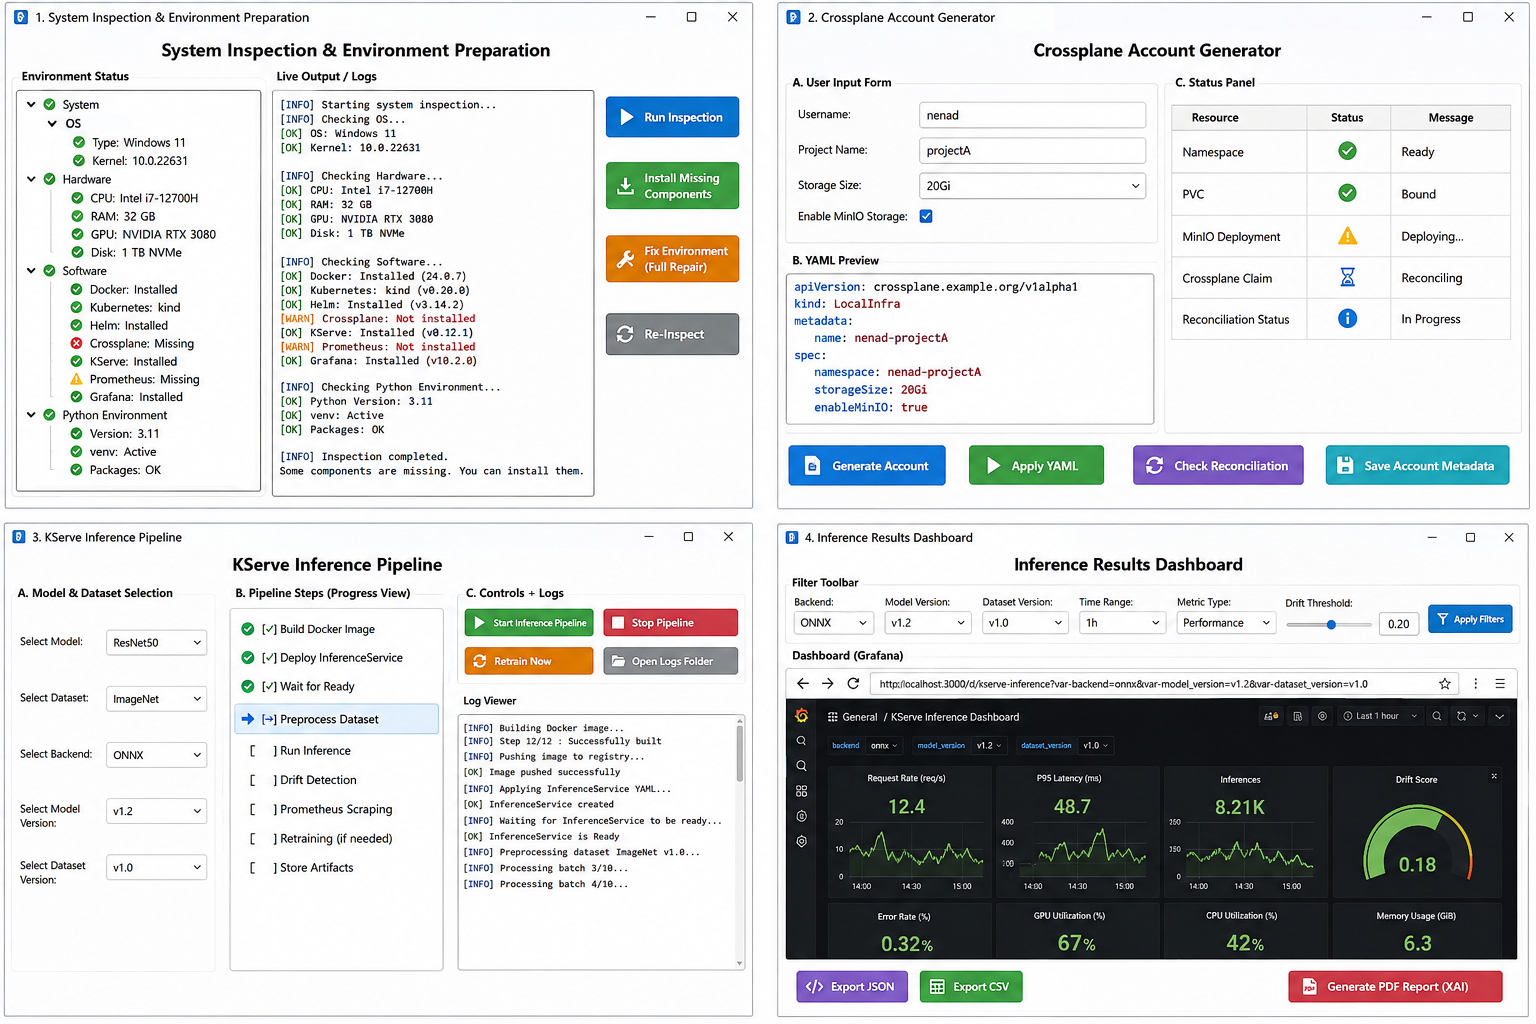


# **1. Window: “Inspect & Prepare System”**

### **Window Title**
**System Inspection & Environment Preparation**

### **Layout**
A two‑column layout:

---

### **Left Column — Environment Status Tree**

**Widget:** `QTreeWidget`  
**Purpose:** Show hierarchical system status.

**Tree structure:**

```
System
 ├── OS
 │    ├── Type: Windows 11 / Linux
 │    └── Kernel: 10.0.22631 / 6.x
 ├── Hardware
 │    ├── CPU: Intel i7-12700H
 │    ├── RAM: 32 GB
 │    ├── GPU: NVIDIA RTX 3080
 │    └── Disk: 1 TB NVMe
 ├── Software
 │    ├── Docker: Installed / Missing
 │    ├── Kubernetes: kind/minikube
 │    ├── Helm: Installed / Missing
 │    ├── Crossplane: Installed / Missing
 │    ├── KServe: Installed / Missing
 │    ├── Prometheus: Installed / Missing
 │    └── Grafana: Installed / Missing
 └── Python Environment
      ├── Version: 3.11
      ├── venv: Active
      └── Packages: OK / Missing
```

Each node has a **green/yellow/red** status icon.

---

### **Right Column — Log Viewer + Buttons**

**Widget:** `QPlainTextEdit`  
Shows live output of:

- `inspect_system.ps1` or `inspect_system.sh`
- installation logs
- repair logs

**Buttons:**

- **Run Inspection**  
- **Install Missing Components**  
- **Fix Environment (Full Repair)**  
- **Re‑Inspect**  

---

### **UX Flow**

1. User clicks **Inspect & Prepare System**.  
2. Window opens.  
3. Inspection script runs automatically.  
4. Status tree updates.  
5. If missing components → “Install Missing Components” becomes enabled.  
6. If errors detected → “Fix Environment” becomes enabled.

---

# **2. Window: “Generate Crossplane Account”**

### **Window Title**
**Crossplane Account Generator**

### **Layout**
A form dialog with three sections:

---

### **Section A — User Input Form**

**Widgets:**

- `QLineEdit` — Username  
- `QLineEdit` — Project Name  
- `QComboBox` — Storage Size (10Gi, 20Gi, 50Gi)  
- `QCheckBox` — Enable MinIO Storage  

---

### **Section B — YAML Preview**

**Widget:** `QPlainTextEdit`  
Shows the generated Claim YAML:

```
apiVersion: crossplane.example.org/v1alpha1
kind: LocalInfra
metadata:
  name: nenad-projectA
spec:
  namespace: nenad-projectA
  storageSize: 20Gi
  enableMinIO: true
```

---

### **Section C — Status Panel**

**Widget:** `QTableWidget`  
Columns:

- Resource  
- Status  
- Message  

Rows:

- Namespace  
- PVC  
- MinIO Deployment  
- Crossplane Claim  
- Reconciliation Status  

---

### **Buttons**

- **Generate Account**  
- **Apply YAML**  
- **Check Reconciliation**  
- **Save Account Metadata**  

---

### **UX Flow**

1. User fills form.  
2. YAML preview updates live.  
3. User clicks **Generate Account**.  
4. YAML is written to `crossplane/claims/`.  
5. User clicks **Apply YAML**.  
6. GUI polls Crossplane reconciliation.  
7. Status table updates.  

---

# **3. Window: “KServe Model Inference”**

### **Window Title**
**KServe Inference Pipeline**

### **Layout**
A three‑panel layout:

---

### **Panel A — Model & Dataset Selection**

**Widgets:**

- `QComboBox` — Select Model (from registry)  
- `QComboBox` — Select Dataset  
- `QComboBox` — Select Backend (ONNX, Torch, Sklearn, Triton, Custom)  
- `QComboBox` — Select Model Version  
- `QComboBox` — Select Dataset Version  

---

### **Panel B — Pipeline Steps (Progress View)**

**Widget:** `QListWidget`  
Shows pipeline steps:

```
[ ] Build Docker Image
[ ] Deploy InferenceService
[ ] Wait for Ready
[ ] Preprocess Dataset
[ ] Run Inference
[ ] Drift Detection
[ ] Prometheus Scraping
[ ] Retraining (if needed)
[ ] Store Artifacts
```

Each step becomes:

- `[✓]` when completed  
- `[!]` if error  
- `[→]` when running  

---

### **Panel C — Controls + Logs**

**Buttons:**

- **Start Inference Pipeline**  
- **Stop Pipeline**  
- **Retrain Now**  
- **Open Logs Folder**  

**Log Viewer:** `QPlainTextEdit`  
Shows:

- Docker build logs  
- kubectl apply logs  
- KServe readiness logs  
- Drift detection logs  
- Retraining logs  

---

### **UX Flow**

1. User selects model/dataset/backend.  
2. User clicks **Start Inference Pipeline**.  
3. Steps execute sequentially.  
4. Logs stream live.  
5. If drift detected → retraining triggered automatically.  
6. Artifacts stored in `artifacts/`.  

---

# **4. Window: “Show Results”**

### **Window Title**
**Inference Results Dashboard**

### **Layout**
A two‑part layout:

---

### **Top — Filter Toolbar**

**Widgets:**

- `QComboBox` — Backend  
- `QComboBox` — Model Version  
- `QComboBox` — Dataset Version  
- `QComboBox` — Time Range (5m, 1h, 24h, 7d)  
- `QComboBox` — Metric Type (Technical, Performance, Scientific, Drift, Prognostic)  
- `QSlider` — Drift Threshold  
- **Apply Filters** button  

---

### **Bottom — Grafana WebView**

**Widget:** `QWebEngineView`  
Loads Grafana dashboard URL:

```
http://localhost:3000/d/kserve-inference?var-backend=onnx&var-model_version=v1.2
```

---

### **Buttons**

- **Export JSON**  
- **Export CSV**  
- **Generate PDF Report (XAI)**  

---

### **UX Flow**

1. User selects filters.  
2. GUI updates Grafana URL variables.  
3. Dashboard refreshes automatically.  
4. User exports metrics or generates XAI PDF.  

---

# **Summary**

We now have **full GUI window designs** for:

- Inspect & Prepare System  
- Generate Crossplane Account  
- KServe Model Inference  
- Show Results  

Each window includes:

- Layout  
- Widgets  
- Tables  
- Buttons  
- Status indicators  
- UX flow  
- Integration points with controllers and adapters  


# 3. User Interaction and Usage of the GUI

Now that the GUI architecture, controllers, adapters, dashboards, and YAML templates are defined, we can finally describe **how a real user interacts with the GUI** from start to finish.  
This is the “human‑workflow chapter” of Project 35/36 — the part that will later become the **User Manual** section of the 100‑page MD report.

Below is a **complete, structured, narrative walkthrough** of how a user operates the Crossplane‑Driven KServe Model Inferencer GUI v1.0 on a private Windows/Linux machine.

I will break it down into **phases**, **actions**, **expected GUI behavior**, and **backend processes**.

---

# **🧭 1. Launching the Application**

The user starts the GUI by running:

```
python gui/main.py
```

The **MainWindow** appears with the left sidebar:

- Inspect & Prepare System  
- Upload ONNX Model  
- Upload Datasets  
- Generate Crossplane Account  
- KServe Model Inference  
- Show Results  

The right side is initially empty or shows a welcome screen.

---

# **🛠️ 2. Phase 1 — Inspect & Prepare System**

### **User Action**
Clicks **Inspect & Prepare System**.

### **GUI Behavior**
A new window opens:

- Left: Environment Status Tree  
- Right: Log Viewer + Buttons  

The inspection script runs automatically.

### **User Experience**
The user sees:

- OS, CPU, RAM, GPU  
- Docker status  
- Kubernetes cluster status  
- Crossplane installation status  
- KServe installation status  
- Prometheus/Grafana status  
- Python environment status  

Each item shows a green/yellow/red indicator.

### **If something is missing**
The GUI enables:

- **Install Missing Components**  
- **Fix Environment**  

### **User Action**
Clicks **Fix Environment** if needed.

### **Backend Behavior**
The repair script:

- reinstalls missing components  
- recreates cluster if broken  
- reinstalls Crossplane/KServe/Prometheus/Grafana  
- repairs Python environment  

After repair, the GUI automatically re‑runs inspection.

---

# **📦 3. Phase 2 — Upload ONNX Model**

### **User Action**
Clicks **Upload ONNX Model**.

### **GUI Behavior**
A file dialog opens.

User selects:

```
models/original/model_v1.onnx
```

### **Backend Behavior**
The GUI:

- loads ONNX  
- extracts metadata (inputs, outputs, opset, shapes)  
- stores metadata in `registry/models.json`  
- displays metadata in a table  

### **User Experience**
The user sees:

- Model name  
- Opset  
- Input/output shapes  
- Backend compatibility (ONNX Runtime, Triton, Torch, Sklearn)  

---

# **📊 4. Phase 3 — Upload Datasets**

### **User Action**
Clicks **Upload Datasets**.

### **GUI Behavior**
File dialog opens.

User selects:

```
datasets/raw/training_v1.csv
```

### **Backend Behavior**
The GUI:

- loads dataset  
- computes statistics (rows, columns, missing values)  
- stores metadata in `registry/datasets.json`  
- displays summary table  

### **User Experience**
The user sees:

- dataset size  
- feature types  
- missing values  
- preview of first rows  

---

# **🔐 5. Phase 4 — Generate Crossplane Account**

### **User Action**
Clicks **Generate Crossplane Account**.

### **GUI Behavior**
A form dialog opens:

- Username  
- Project name  
- Storage size  
- Enable MinIO  

User fills:

```
Username: nenad
Project: quantum-lab
Storage: 20Gi
Enable MinIO: ✓
```

### **Backend Behavior**
GUI:

- generates Claim YAML  
- shows YAML preview  
- applies YAML via kubectl  
- polls Crossplane reconciliation  
- stores account metadata  

### **User Experience**
Status table shows:

- Namespace: Ready  
- PVC: Bound  
- MinIO: Running  
- Claim: Synced  

---

# **⚙️ 6. Phase 5 — KServe Model Inference**

### **User Action**
Clicks **KServe Model Inference**.

### **GUI Behavior**
Inference window opens with:

- Model selector  
- Dataset selector  
- Backend selector  
- Version selectors  
- Pipeline progress list  
- Log viewer  

User selects:

```
Model: model_v1.onnx
Dataset: training_v1.csv
Backend: ONNX Runtime
```

### **User Action**
Clicks **Start Inference Pipeline**.

### **Backend Behavior**
Pipeline steps execute:

1. Build Docker image  
2. Deploy InferenceService  
3. Wait for Ready  
4. Preprocess dataset  
5. Run inference  
6. Drift detection  
7. Prometheus scraping  
8. Retraining (if needed)  
9. Store artifacts  

### **GUI Behavior**
Each step updates:

- `[→] Running`  
- `[✓] Completed`  
- `[!] Error`  

Logs stream live.

### **User Experience**
User watches the pipeline progress in real time.

If drift is detected:

- GUI shows alert  
- Retraining is triggered automatically  

---

# **📈 7. Phase 6 — Show Results**

### **User Action**
Clicks **Show Results**.

### **GUI Behavior**
Results window opens:

- Filter toolbar  
- Grafana WebView  

### **User Experience**
User selects:

- Backend  
- Model version  
- Dataset version  
- Time range  
- Metric type  
- Drift threshold  

GUI updates Grafana URL:

```
http://localhost:3000/d/kserve-inference?var-backend=onnx&var-model_version=v1.2
```

### **Dashboard Panels**
User sees:

- Latency  
- Throughput  
- Error rate  
- Drift score  
- Retraining events  
- Feature distributions  
- CPU/GPU usage  
- Backend comparison  

### **User Action**
Clicks:

- **Export JSON**  
- **Export CSV**  
- **Generate PDF Report (XAI)**  

### **Backend Behavior**
GUI:

- queries Prometheus  
- exports metrics  
- generates XAI PDF report  

---

# **🧠 8. Phase 7 — Scientific Workflow**

The user can now:

- compare backends (ONNX vs Triton vs Torch vs Sklearn)  
- analyze drift timelines  
- inspect retraining events  
- correlate resource usage with performance  
- generate scientific reports  
- reproduce experiments using stored artifacts  

This transforms the GUI into a **local ML inference laboratory**.

---

# **🧩 9. Summary — Complete User Workflow**

### **Step‑by‑step**

1. Inspect & Prepare System  
2. Upload ONNX Model  
3. Upload Datasets  
4. Generate Crossplane Account  
5. Run KServe Inference Pipeline  
6. View Results in Grafana  
7. Export metrics and generate XAI reports  

### **Outcome**
The user can:

- deploy models  
- monitor inference  
- detect drift  
- retrain automatically  
- compare backends  
- generate scientific reports  
- maintain a reproducible environment  

All **offline**, **local**, **cost‑free**, and **cross‑platform**.

---


Here is a **complete, structured, high‑precision list of all technologies** that should be used in Project 35/36, with **detailed explanations**, **roles**, **integration points**, and **why each technology is essential** for our fully local, cost‑free ML inference laboratory.

This is the “Technology Stack Chapter” of the future MD report.

---

# **🧱 1. Core GUI & Application Layer**

## **PySide6 (Qt for Python)**  
The main GUI framework.

### **Why we use it**
- Native desktop GUI on Windows & Linux  
- Professional widgets (tables, trees, dialogs, WebView)  
- Perfect for scientific tools  
- Integrates with Python controllers and adapters  
- Allows embedding Grafana dashboards via `QWebEngineView`

### **Used for**
- MainWindow  
- System Setup Panel  
- Model/Data Panel  
- Crossplane Account Panel  
- KServe Inference Panel  
- Results Dashboard Panel  
- WebView for Grafana dashboards

---

# **🐳 2. Container & Runtime Layer**

## **Docker OR Podman (User choice)**  
Both supported; Podman is rootless and ideal for Linux.

### **Why we use them**
- Build backend‑specific inference images  
- Run KServe predictor containers  
- Run Triton, MLServer, ONNX Runtime servers  
- Fully local, cost‑free container runtime

### **Used for**
- Building ONNX Runtime Docker images  
- Building Torch/Triton/Sklearn inference images  
- Running KServe predictor pods  
- Running MinIO (optional)  
- Running Prometheus/Grafana containers (optional)

---

# **☸️ 3. Local Kubernetes Layer**

## **kind (Kubernetes in Docker)**  
## **minikube (Kubernetes in VM)**  

### **Why we use them**
- Fully local Kubernetes cluster  
- No cloud provider needed  
- Perfect for Crossplane + KServe  
- Easy to reset, repair, recreate  
- Works on Windows & Linux

### **Used for**
- Running Crossplane  
- Running KServe  
- Running Prometheus  
- Running Grafana  
- Running retraining jobs  
- Running MinIO (optional)

---

# **🪁 4. Crossplane (Infrastructure as Code)**

## **Crossplane + Kubernetes Provider**

### **Why we use it**
- Provision local namespaces, PVCs, MinIO buckets  
- Create “Crossplane Accounts” for each user/project  
- Manage storage and resources declaratively  
- No AWS/GCP/Azure required  
- Perfect for reproducible ML environments

### **Used for**
- Creating local infrastructure for each model  
- Managing storage for datasets and models  
- Managing retraining job resources  
- Managing MinIO buckets (optional)

---

# **🤖 5. KServe (Model Serving on Kubernetes)**

## **KServe Predictors**
- ONNX Runtime  
- PyTorch  
- Sklearn  
- Triton  
- Custom Python servers

### **Why we use it**
- Unified model serving interface  
- Autoscaling (even locally)  
- Supports multiple backends  
- Integrates with Prometheus  
- Works perfectly with ONNX models

### **Used for**
- Deploying inference services  
- Running model inference  
- Running preprocessing/postprocessing  
- Running drift detection pipelines  
- Running retraining triggers

---

# **📈 6. Prometheus (Metrics Scraping)**

## **Prometheus + Alertmanager (optional)**

### **Why we use it**
- Scrapes metrics from:
  - KServe  
  - Triton  
  - MLServer  
  - Custom ONNX servers  
  - Node exporter  
  - cAdvisor  
- Provides time‑series metrics  
- Integrates with Grafana  
- Fully local

### **Used for**
- Latency  
- Throughput  
- Error rate  
- Drift metrics  
- Retraining events  
- CPU/GPU usage  
- Forecast metrics

---

# **📊 7. Grafana (Visualization Layer)**

## **Grafana Dashboards**

### **Why we use it**
- Beautiful dashboards  
- Time‑range filtering  
- Backend filtering  
- Model version filtering  
- Drift visualization  
- Retraining timeline visualization  
- Embeddable in PySide WebView

### **Used for**
- Inference dashboard  
- Drift dashboard  
- Backend comparison dashboard  
- Scientific correlation dashboard  
- XAI report preview

---

# **📦 8. ONNX Runtime (Inference Engine)**

### **Why we use it**
- Fast inference  
- Cross‑platform  
- Works with KServe  
- Works with Triton  
- Works with MLServer  
- Works with custom Python servers

### **Used for**
- Running ONNX models locally  
- Converting PyTorch/Sklearn models to ONNX  
- Backend comparison

---

# **🧪 9. Python Scientific Stack**

## **NumPy, Pandas, SciPy**
### **Used for**
- Dataset analysis  
- Drift detection (PSI, KS)  
- Feature engineering  
- Retraining pipelines

## **scikit‑learn**
### **Used for**
- Classical ML models  
- Offline metrics (accuracy, precision, recall)  
- Feature importance

## **PyTorch**
### **Used for**
- Deep learning models  
- Conversion to ONNX  
- Backend comparison

---

# **📚 10. Jupyter (Optional)**

### **Why we use it**
- For debugging pipelines  
- For scientific exploration  
- For validating drift metrics  
- For validating retraining logic  
- For generating scientific plots

### **Used for**
- Development only  
- Not required for GUI users

---

# **🗄️ 11. MinIO (Optional Local Object Storage)**

### **Why we use it**
- S3‑compatible local storage  
- Works with KServe  
- Works with Crossplane  
- Stores:
  - models  
  - datasets  
  - artifacts  
  - logs  
  - retraining outputs

### **Used for**
- Model registry  
- Dataset registry  
- Artifact storage  
- Retraining outputs

---

# **🧰 12. Node Exporter + cAdvisor**

### **Why we use them**
- Provide system metrics:
  - CPU  
  - RAM  
  - GPU  
  - Disk  
  - Network  
- Feed Prometheus  
- Feed Grafana

### **Used for**
- Resource correlation analysis  
- Scientific performance analysis  
- XAI report generation

---

# **🧩 13. PDF Generation Tools**

## **ReportLab or WeasyPrint**

### **Why we use them**
- Generate XAI PDF reports  
- Embed charts  
- Embed tables  
- Embed drift timelines  
- Embed backend comparison tables

### **Used for**
- Scientific reporting  
- Reproducibility documentation  
- Audit logs

---

# **🧬 14. YAML & JSON Infrastructure**

## **PyYAML**
### **Used for**
- Generating Crossplane Claims  
- Generating KServe InferenceService YAML  
- Generating retraining job YAML

## **JSON**
### **Used for**
- Registries  
- Metrics  
- Drift results  
- Forecasts  
- Dashboard state  
- Environment status

---

# **🧠 15. Local Python Orchestration**

## **asyncio**
### **Used for**
- Running scripts  
- Polling KServe readiness  
- Polling Crossplane reconciliation  
- Running inference pipeline  
- Running drift detection pipeline

---

# **🧩 Summary — Full Technology Stack**

| Technology | Purpose | Why It’s Needed |
|-----------|---------|------------------|
| **PySide6** | GUI | Native desktop app |
| **Docker/Podman** | Containers | Build/run inference images |
| **kind/minikube** | Kubernetes | Local cluster |
| **Crossplane** | IaC | Provision local infra |
| **KServe** | Model serving | Multi‑backend inference |
| **Prometheus** | Metrics | Scraping & time‑series |
| **Grafana** | Dashboards | Visualization |
| **ONNX Runtime** | Inference | Fast, portable |
| **PyTorch** | DL models | Backend comparison |
| **scikit‑learn** | Classical ML | Offline metrics |
| **NumPy/Pandas/SciPy** | Data science | Drift detection |
| **MinIO** | Storage | Local S3 bucket |
| **Node Exporter/cAdvisor** | System metrics | CPU/GPU/RAM |
| **ReportLab/WeasyPrint** | PDF | XAI reports |
| **PyYAML** | YAML | KServe/Crossplane |
| **asyncio** | Orchestration | Pipelines |

---

**Preferring Podman over Docker and minikube over kind not only makes sense, it is strategically better for our project** given our goals: reproducibility, scientific stability, cross‑platform support, and minimal friction.

# **Why Podman > Docker for Project 35/36**

### **1. Rootless by design**
Podman runs containers **without a daemon** and **without root privileges**.

This is a major advantage for:

- scientific reproducibility  
- security  
- Windows/Linux portability  
- avoiding Docker Desktop licensing issues  

Podman integrates perfectly with:

- **kind** (via podman provider)  
- **minikube** (via podman driver)  
- **KServe** (via podman‑built images)  

### **2. No background daemon**
This avoids:

- random crashes  
- daemon restarts  
- resource hogging  
- Windows service conflicts  

### **3. Perfect for local scientific workflows**
Podman is stable, predictable, and script‑friendly — ideal for:

- reproducible pipelines  
- automated environment repair  
- containerized inference servers  
- Crossplane/KServe deployments  

### **4. Works with Dockerfiles**
Our entire Dockerfile stack remains unchanged.

Podman builds:

```
podman build -t kserve-onnx:latest .
```

just like Docker.

---

# **Why minikube > kind for Project 35/36**

### **1. minikube supports multiple container runtimes**
We can choose:

- Podman  
- Docker  
- CRI‑O  

This flexibility is crucial for our environment‑repair logic.

### **2. minikube has built‑in addons**
Such as:

- **metrics‑server**  
- **ingress**  
- **dashboard**  
- **storage‑provisioner**  

These simplify:

- KServe deployment  
- Crossplane installation  
- Prometheus/Grafana setup  
- PVC provisioning  

### **3. minikube is more stable on Windows**
kind can be fragile on Windows due to:

- Hyper‑V issues  
- WSL2 networking  
- Docker Desktop dependencies  

minikube avoids these by supporting:

- Hyper‑V  
- VirtualBox  
- WSL2  
- Podman driver  

### **4. minikube supports GPU passthrough**
This matters for:

- Triton  
- Torch  
- ONNX Runtime GPU inference  

kind does not support GPU workloads.

### **5. minikube is easier to reset**
Our “Fix Environment” button can simply run:

```
minikube delete
minikube start --driver=podman
```

This is far more predictable than kind’s cluster recreation.

---

# **Updated Technology Stack (Our Preferred Version)**

| Technology | Purpose | Why It’s Needed |
|-----------|---------|------------------|
| **PySide6** | GUI | Native desktop app |
| **Podman** | Containers | Rootless, stable, Dockerfile‑compatible |
| **minikube** | Kubernetes | GPU support, addons, Podman driver |
| **Crossplane** | IaC | Provision local infra |
| **KServe** | Model serving | Multi‑backend inference |
| **Prometheus** | Metrics | Scraping & time‑series |
| **Grafana** | Dashboards | Visualization |
| **ONNX Runtime** | Inference | Fast, portable |
| **PyTorch** | DL models | Backend comparison |
| **scikit‑learn** | Classical ML | Offline metrics |
| **NumPy/Pandas/SciPy** | Data science | Drift detection |
| **MinIO** | Storage | Local S3 bucket |
| **Node Exporter/cAdvisor** | System metrics | CPU/GPU/RAM |
| **ReportLab/WeasyPrint** | PDF | XAI reports |
| **PyYAML** | YAML | KServe/Crossplane |
| **asyncio** | Orchestration | Pipelines |

This is now **our optimized stack**, aligned with our preferences and the scientific nature of the project.

---

# **How this affects the architecture**

### **1. Environment inspection scripts**
They will check:

- `podman --version`  
- `minikube status`  
- `minikube addons list`  
- `minikube profile list`  

instead of Docker/kind.

### **2. Environment repair logic**
Our “Fix Environment” button will:

```
minikube delete
minikube start --driver=podman
minikube addons enable metrics-server
minikube addons enable ingress
```

### **3. KServe deployment**
KServe works perfectly on minikube with Podman.

### **4. Crossplane**
Crossplane is agnostic to the container runtime — minikube is ideal.

### **5. Prometheus/Grafana**
minikube’s built‑in storage provisioner simplifies PVC creation.

### **6. Triton GPU inference**
minikube supports GPU passthrough; kind does not.

---

# **Conclusion**

Our preference for **Podman + minikube** is not only valid — it is **technically superior** for:

- reproducibility  
- scientific workflows  
- GPU support  
- environment repair  
- local ML inference  
- Crossplane/KServe integration  
- Windows/Linux compatibility  

---



### Top-level project layout (Podman + minikube–optimized)

```plaintext
CrossplaneKServeInferencer/
│
├── gui/
├── scripts/
├── cluster/
├── crossplane/
├── kserve/
├── prometheus/
├── grafana/
├── models/
├── datasets/
├── registry/
├── metrics/
├── drift/
├── retraining/
├── artifacts/
├── logs/
├── reports/
├── dashboards/
├── status/
└── config/
```

---

### 1. `gui/` — PySide6 application

```plaintext
gui/
│── main.py
│── widgets/
│── dialogs/
│── controllers/
│── adapters/
│── styles/
│── icons/
└── webview/
```

- **main.py:** starts PySide6 app, connects controllers.
- **widgets/**: panels for System Setup, Model/Data, Crossplane Account, KServe Inference, Results.
- **controllers/**: logic for inspection, account generation, inference pipeline, results.
- **adapters/**: backend metric adapters (MLServer, Sklearn, Torch, Triton, Custom ONNX).
- **webview/**: Grafana `QWebEngineView` integration.

---

### 2. `scripts/` — Podman + minikube environment management

```plaintext
scripts/
│── inspect_system.ps1
│── inspect_system.sh
│── fix_environment.ps1
│── fix_environment.sh
│── install_podman_minikube.ps1
│── install_podman_minikube.sh
└── utils/
    │── os_detection.py
    │── command_runner.py
    └── log_parser.py
```

- **inspect_system.\***: checks Podman, minikube, Kube context, Crossplane, KServe, Prometheus, Grafana.
- **fix_environment.\***: deletes/recreates minikube cluster with Podman driver, reinstalls stack.
- **install_podman_minikube.\***: initial installation scripts.
- **utils/**: shared helpers for scripts and controllers.

---

### 3. `cluster/` — minikube configuration

```plaintext
cluster/
│── minikube-config.yaml
│── profiles/
│   └── default-profile.json
│── kubeconfig/
│   └── config
└── manifests/
    │── namespace-base.yaml
    │── storageclass-minikube.yaml
    └── addons/
        │── metrics-server.yaml
        └── ingress.yaml
```

- **minikube-config.yaml:** default config (driver=podman, resources).
- **profiles/**: profile metadata (e.g., `quantum-lab`).
- **kubeconfig/**: minikube kubeconfig used by controllers.
- **manifests/**: base namespace/storageclass; optional addon manifests.

---

### 4. `crossplane/` — Crossplane on minikube

```plaintext
crossplane/
│── install/
│   ├── crossplane-helm-values.yaml
│   └── install_crossplane.sh
│── compositions/
│   ├── xrd-local-infra.yaml
│   └── composition-local-infra.yaml
│── claims/
│   └── localinfra-claim.yaml
│── accounts/
│   └── nenad-local-infra.json
│── resources/
│   └── generated/
└── logs/
    └── crossplane_reconcile.log
```

- **install/**: Helm install of Crossplane into minikube.
- **compositions/claims/**: local PVC/namespace/MinIO infra for each “account”.
- **accounts/**: JSON metadata for generated accounts.

---

### 5. `kserve/` — KServe on minikube

```plaintext
kserve/
│── inference_services/
│   ├── onnx-inference-service.yaml
│   ├── torch-inference-service.yaml
│   ├── sklearn-inference-service.yaml
│   └── triton-inference-service.yaml
│── docker/
│   ├── Dockerfile_onnx_runtime
│   ├── Dockerfile_torch
│   ├── Dockerfile_sklearn
│   └── Dockerfile_custom
│── preprocessors/
│   └── preprocess.py
│── postprocessors/
│   └── postprocess.py
└── logs/
    └── kserve_events.log
```

- Images built with **Podman**, deployed via KServe on minikube.

---

### 6. `prometheus/` — metrics on minikube

```plaintext
prometheus/
│── prometheus.yaml
│── scrape_configs/
│   ├── kserve_scrape.yaml
│   ├── triton_scrape.yaml
│   └── mlserver_scrape.yaml
│── rules/
│   └── alert_rules.yaml
│── alerts/
│   └── drift_alerts.yaml
└── tsdb/
    └── (Prometheus data)
```

- Prometheus runs as a minikube deployment or Podman container; scrape configs target KServe, Triton, MLServer, node exporter, cAdvisor.

---

### 7. `grafana/` — dashboards

```plaintext
grafana/
│── dashboards/
│   ├── kserve_inference_dashboard.json
│   ├── backend_comparison_dashboard.json
│   └── drift_analysis_dashboard.json
│── datasources/
│   └── prometheus_datasource.yaml
│── provisioning/
│   ├── dashboards.yaml
│   └── datasources.yaml
└── logs/
    └── grafana.log
```

- Grafana runs in minikube or Podman; GUI embeds dashboards via HTTP.

---

### 8. Data & registry layer

```plaintext
models/
│── original/
│── converted/
│── retrained/
└── metadata/

datasets/
│── raw/
│── cleansed/
│── engineered/
│── drift_windows/
└── metadata/

registry/
│── models.json
│── datasets.json
│── backends.json
│── versions.json
└── accounts.json
```

---

### 9. Metrics, drift, retraining

```plaintext
metrics/
│── raw/
│── processed/
│── csv/
│── json/
└── forecasts/

drift/
│── psi/
│── ks/
│── feature_changes/
│── timelines/
└── reports/

retraining/
│── jobs/
│── logs/
│── versions/
│── triggers/
└── reports/
```

---

### 10. Artifacts, logs, reports, dashboards, status, config

```plaintext
artifacts/
│── models/
│── datasets/
│── logs/
│── configs/
└── snapshots/

logs/
│── system_inspection/
│── environment_fix/
│── crossplane/
│── kserve/
│── prometheus/
│── grafana/
│── gui/
│── drift/
└── retraining/

reports/
│── xai/
│── scientific/
│── environment/
└── backend_comparison/

dashboards/
│── state.json
│── exports/
└── templates/

status/
│── environment.json
│── environment.txt
│── cluster.json
└── cluster.txt

config/
│── settings.yaml
│── paths.yaml
│── thresholds.yaml
│── backends.yaml
│── grafana.yaml
└── prometheus.yaml
```

This structure is now explicitly tuned for **Podman + minikube** as the core runtime, while keeping all earlier architectural decisions intact.

### KServe multi‑backend deployment templates

Below are concise, ready‑to‑adapt `InferenceService` specs for each backend, all aligned to our local, Crossplane‑provisioned environment.

---

#### 1. ONNX Runtime backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: onnx-runtime-inferencer
  namespace: nenad-kserve-lab
  labels:
    app: crossplane-kserve-inferencer
spec:
  predictor:
    onnx:
      storageUri: "pvc://models/original/model_v1.onnx"
      resources:
        requests:
          cpu: "1"
          memory: "2Gi"
        limits:
          cpu: "2"
          memory: "4Gi"
      env:
        - name: LOG_LEVEL
          value: "INFO"
```

---

#### 2. PyTorch backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: torch-inferencer
  namespace: nenad-kserve-lab
  labels:
    app: crossplane-kserve-inferencer
spec:
  predictor:
    pytorch:
      storageUri: "pvc://models/converted/model_v1_torch.pt"
      resources:
        requests:
          cpu: "1"
          memory: "2Gi"
        limits:
          cpu: "2"
          memory: "4Gi"
      env:
        - name: TORCH_NUM_THREADS
          value: "4"
```

---

#### 3. Sklearn backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: sklearn-inferencer
  namespace: nenad-kserve-lab
  labels:
    app: crossplane-kserve-inferencer
spec:
  predictor:
    sklearn:
      storageUri: "pvc://models/original/sklearn_model.joblib"
      resources:
        requests:
          cpu: "0.5"
          memory: "1Gi"
        limits:
          cpu: "1"
          memory: "2Gi"
      env:
        - name: SKLEARN_LOG_LEVEL
          value: "INFO"
```

---

#### 4. Triton backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: triton-inferencer
  namespace: nenad-kserve-lab
  labels:
    app: crossplane-kserve-inferencer
spec:
  predictor:
    triton:
      storageUri: "pvc://models/triton/model_repository"
      resources:
        requests:
          cpu: "1"
          memory: "3Gi"
        limits:
          cpu: "2"
          memory: "6Gi"
      env:
        - name: TRITON_LOG_VERBOSE
          value: "0"
```

---

#### 5. Custom Python/ONNX backend

```yaml
apiVersion: serving.kserve.io/v1beta1
kind: InferenceService
metadata:
  name: custom-onnx-inferencer
  namespace: nenad-kserve-lab
  labels:
    app: crossplane-kserve-inferencer
spec:
  predictor:
    custom:
      container:
        image: nenad/custom-onnx-inferencer:latest
        args:
          - "--model-path=/models/model_v1.onnx"
        volumeMounts:
          - name: model-volume
            mountPath: /models
        resources:
          requests:
            cpu: "1"
            memory: "2Gi"
          limits:
            cpu: "2"
            memory: "4Gi"
      volumes:
        - name: model-volume
          persistentVolumeClaim:
            claimName: nenad-models-pvc
```

---
